In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, kruskal, chi2_contingency, shapiro, johnsonsb, norm
from statsmodels.tsa.stattools import adfuller


import warnings
warnings.simplefilter('ignore')

In [183]:
past_recent_long = pd.read_csv("eu_merged.csv")

In [184]:
past_recent_long.head()

,Country Name,Country Code,Year,Electric Power Consumption,Energy use
0,Austria,AUT,1960,1814.676017,1546.261468
1,Austria,AUT,1961,1882.223711,1554.034906
2,Austria,AUT,1962,2006.770396,1675.873621
3,Austria,AUT,1963,2124.359184,1823.995225
4,Austria,AUT,1964,2232.896504,1855.085155


In [185]:
past_recent_long.shape

(1701, 5)

In [186]:
# Filtering data for Ireland and France
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland'][['Electric Power Consumption', 'Energy use']]
France_data = past_recent_long[past_recent_long['Country Name'] == 'France'][['Electric Power Consumption', 'Energy use']]

In [187]:
Ireland_data.isnull().sum()

Electric Power Consumption    0
Energy use                    0
dtype: int64

In [188]:
Ireland_data.head().reset_index(drop=True)

,Electric Power Consumption,Energy use
0,695.043484,1318.812487
1,752.018128,1396.466152
2,838.137550,1412.729677
3,886.193539,1453.962105
4,1041.670301,1522.194973


In [189]:
France_data.head().reset_index(drop=True)

,Electric Power Consumption,Energy use
0,1438.298605,1670.892037
1,1528.848735,1720.959170
2,1637.648122,1842.403115
3,1740.594003,1971.496945
4,1890.327523,2077.947403


In [190]:
France_data.isnull().sum()

Electric Power Consumption    0
Energy use                    0
dtype: int64

# Statistics: Descriptive Statistics

Descriptive statistics such as mean, median, mode is calculated to measure the central tendency in the data, while range, variance, and standard deviation is calculated to measure the dispersion in the data. 

The project calculates the descriptive statistics to answer following questions:

#### Mean

#### Problem statement: What is the average per capita energy consumption in Ireland from 1960 to 2022?

In [195]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
        mean = Ireland_data[features].mean()
        print(f"Mean of {features}: {mean:.2f}")        

Mean of Electric Power Consumption: 3926.82
Mean of Energy use: 2612.55


#### 25th Percentile

#### Problem statement: Can we identify the threshold for the lowest quarter of features in Ireland Dataset?.

In [198]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
        Q1 = Ireland_data[features].quantile(0.25)
        print(f"Q1 of {features}: {Q1:.2f}") 

Q1 of Electric Power Consumption: 2311.86
Q1 of Energy use: 2221.15


#### 75th Percentile

#### Problem statement: Can we determine the energy consumption threshold that separates the top quartile of consumption level from the rest?

In [201]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
        Q1 = Ireland_data[features].quantile(0.75)
        print(f"Q3 of {features}: {Q1:.2f}") 

Q3 of Electric Power Consumption: 5823.00
Q3 of Energy use: 2946.76


#### Median

#### Problem statement: Can we determine the energy consumption value that divides the per capita consumption into two equal halves?

In [204]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
    median = Ireland_data[features].median()
    print(f"Median of {features}: {median}")

Median of Electric Power Consumption: 3897.873231406514
Median of Energy use: 2659.00152476651


#### Mode

#### Problem statement: Can we identify the frequent consumption amount in given period?

In [207]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
        mode=  Ireland_data[features].mode()   
        print(f"mode of {features}: {mode}")

mode of Electric Power Consumption: 0      695.043484
1      752.018128
2      838.137550
3      886.193539
4     1041.670301
         ...     
58    6168.398988
59    6218.313404
60    6241.715574
61    6340.733045
62    6351.099111
Name: Electric Power Consumption, Length: 63, dtype: float64
mode of Energy use: 0     1318.812487
1     1396.466152
2     1412.729677
3     1453.962105
4     1511.904911
         ...     
58    3544.387616
59    3558.085941
60    3626.747161
61    3661.322241
62    3713.513869
Name: Energy use, Length: 63, dtype: float64


#### Minimum value

#### Problem statement: Can we identify the lowest observed values in the given dataset?

In [210]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
    min = Ireland_data[features].min()
    print(f"Minimum of {features}: {min}")

Minimum of Electric Power Consumption: 695.0434844092484
Minimum of Energy use: 1318.812486742558


#### Maximum value

#### Problem statement: What is the highest energy consumption in the Ireland dataset?

In [213]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
    max = Ireland_data[features].max()
    print(f"Maximum of {features}: {max}")

Maximum of Electric Power Consumption: 6351.099110794646
Maximum of Energy use: 3713.51386863164


#### Range

#### Problem statement: How large is the difference between the absolute maximum and minimum energy consumption recorded?

In [216]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
        range_1 = Ireland_data[features].max() - Ireland_data[features].min()
        print(f"Range of {features}: {range_1}")

Range of Electric Power Consumption: 5656.055626385397
Range of Energy use: 2394.701381889082


#### Variance

#### Problem statement: How much does the squared deviation from the mean energy consumption vary within Ireland dataset?

In [219]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
        variance = Ireland_data[features].var()
        print(f"Variance of {features}: {variance:.2f}")   

Variance of Electric Power Consumption: 3541525.10
Variance of Energy use: 392782.77


#### Standard Deviation

#### Problem statement: How much, on average, do individual energy consumption values deviate from the mean?

In [222]:
for features in Ireland_data.select_dtypes(include=['number']).columns:
        deviation = Ireland_data[features].std()
        print(f"Standard Deviation of {features}: {deviation:.2f}")        

Standard Deviation of Electric Power Consumption: 1881.89
Standard Deviation of Energy use: 626.72


In [223]:
Ireland_data.describe(exclude=['int'])

,Electric Power Consumption,Energy use
count,63.000000,63.000000
mean,3926.817692,2612.552332
std,1881.894019,626.723835
min,695.043484,1318.812487
25%,2311.860674,2221.146653
50%,3897.873231,2659.001525
75%,5822.998633,2946.763168
max,6351.099111,3713.513869


**Interpretation:** 

**Electric Power Consumption**: 

The dataset contains 63 observations. The mean is the sum of all observed values divided by the number of observed vaules in the dataset. The median is the middlemost number in a set of numbers when the data is ordered from lowest to highest. median is 50th percentile of the data. The data tend to cluster around 3900 (mean) and 3897 (median). 

As the median and mean values are closer to each other, it can be estimated that data is likely to have a less dispersed distribution. 

Python's std() method calculates the one standard deviation. It is used to measure how the data spread out around the mean. The data points are ± 1881.89 away from the mean. Under the normality rule, 68% of data are between 2044.93 and 5808.71. If we multiply the standard deviation by 2, we get 2nd standard deviation. 95% of data lies between 163.04 and 7690.60. ~99.7% of the data falls within 3rd standard deviation which is between -1719.85 and 9573.48. However, the values of electric power consumption can never be zero. It can be suggested that data is not following normality. The influence of outliers is making higher tail. 

Distance to Q2 is calculated to assess whether the distribution is symmetric or not. 25th percentile is closer to 50th percentile than to 75th percentile, which means that the data can be estimated that data can be positively skewed. However, the higher values at the upper end can make right tail heavy and longer. It can be suggested the possible outliers are in the larger values. 

The data's minimum value is 695, while its maximum value is 6351. The data's range is 6,286.02. The higher the range, the more spread out the data, or the presence of one or two lowest and highest values could influence the high variability in the spread of data. 

**Energy use**: 

The data tend to cluster around 2612 (mean) and 2659 (median). 

As the median and mean values are closer to each other, it can be estimated that data is likely to have less dispersed distribution. 

Python's std() method calculates the one standard deviation. It is used to measure how the data spread out around the mean. The data points are ± 626 away from the mean. Under the normality rule, 68% of data are between 1,985.8 and 3,239.27. If we multiply the standard deviation by 2, we get 2nd standard deviation. 95% of data lies between 1359.11 and 3866. ~99.7% of the data falls within 3rd standard deviation which is between 732.39 and 4492.71.  It can be suggested that data is not following normality. Values beyond 3rd standard deviation are extreme outliers.

75th percentile is closer to 50th percentile than to 25th percentile, which means that the data can be estimated that data can be slightly negatively skewed. It can be suggested the possible outliers are in the larger values. 

The minimum value of the data is 1318, while the maximum value of the data is 3713. The range of data is 2,395. The higher the range, the more spread out the data it is or it can be the presence of one or two lowest and highest values could influence the high variability in the spread of data. 

**Key observations:**

+ The range of data in electric power consumption is more spread than the range of data in energy use.
+ The data of energy use variable closely clustered around the lower values
+ There may be significant difference distribution between two variables

### Descriptive Statistics on France's Dataset

#### Mean

#### Problem statement: What is the average per capita energy consumption in France from 1960 to 2022?

In [228]:
for features in France_data.select_dtypes(include=['number']).columns:
        mean = France_data[features].mean()
        print(f"Mean of {features}: {mean:.2f}")        

Mean of Electric Power Consumption: 5361.11
Mean of Energy use: 3452.17


#### 25th Percentile

#### Problem statement: Can we identify the threshold for the lowest quarter of features in France's Dataset?.

In [231]:
for features in France_data.select_dtypes(include=['number']).columns:
        Q1 = France_data[features].quantile(0.25)
        print(f"Q1 of {features}: {Q1:.2f}") 

Q1 of Electric Power Consumption: 3424.83
Q1 of Energy use: 3198.09


#### Median

#### Problem statement: Can we determine the energy consumption value that divides the per capita consumption into two equal halves?

In [234]:
for features in France_data.select_dtypes(include=['number']).columns:
    median = France_data[features].median()
    print(f"Median of {features}: {median}")

Median of Electric Power Consumption: 6360.324842049872
Median of Energy use: 3659.087794684488


#### Mode

#### Problem statement: Can we identify the frequent consumption amount in given period?

In [237]:
for features in France_data.select_dtypes(include=['number']).columns:
        mode=  France_data[features].mode()   
        print(f"mode of {features}: {mode}")

mode of Electric Power Consumption: 0     1438.298605
1     1528.848735
2     1637.648122
3     1740.594003
4     1890.327523
         ...     
58    7540.181404
59    7643.434771
60    7652.682251
61    7661.162155
62    7734.880939
Name: Electric Power Consumption, Length: 63, dtype: float64
mode of Energy use: 0     1670.892037
1     1720.959170
2     1842.403115
3     1971.496945
4     2077.947403
         ...     
58    4224.997995
59    4245.524256
60    4270.608534
61    4287.055427
62    4301.552485
Name: Energy use, Length: 63, dtype: float64


#### Minimum value

#### Problem statement: Can we identify the lowest observed values in the given dataset?

In [240]:
for features in France_data.select_dtypes(include=['number']).columns:
    min = France_data[features].min()
    print(f"Minimum of {features}: {min}")

Minimum of Electric Power Consumption: 1438.298605419395
Minimum of Energy use: 1670.892037038646


#### Maximum value

#### Problem statement: What is the highest energy consumption in the France dataset?

In [243]:
for features in France_data.select_dtypes(include=['number']).columns:
    max = France_data[features].max()
    print(f"Maximum of {features}: {max}")

Maximum of Electric Power Consumption: 7734.880939010886
Maximum of Energy use: 4301.552485163359


#### Range

#### Problem statement: How large is the difference between the absolute maximum and minimum energy consumption recorded?

In [246]:
for features in France_data.select_dtypes(include=['number']).columns:
        range_1 = France_data[features].max() - France_data[features].min()
        print(f"Range of {features}: {range_1}")

Range of Electric Power Consumption: 6296.582333591491
Range of Energy use: 2630.660448124713


#### Variance

#### Problem statement: How much does the squared deviation from the mean energy consumption vary within France dataset?

In [249]:
for features in France_data.select_dtypes(include=['number']).columns:
        variance = France_data[features].var()
        print(f"Variance of {features}: {variance:.2f}")   

Variance of Electric Power Consumption: 4354603.06
Variance of Energy use: 501919.45


#### Standard Deviation

#### Problem statement: How much, on average, do individual energy consumption values deviate from the mean?

In [252]:
for features in France_data.select_dtypes(include=['number']).columns:
        deviation = France_data[features].std()
        print(f"Standard Deviation of {features}: {deviation:.2f}")        

Standard Deviation of Electric Power Consumption: 2086.77
Standard Deviation of Energy use: 708.46


In [253]:
France_data.describe(exclude=['int'])

,Electric Power Consumption,Energy use
count,63.000000,63.000000
mean,5361.112423,3452.168393
std,2086.768568,708.462740
min,1438.298605,1670.892037
25%,3424.833296,3198.094725
50%,6360.324842,3659.087795
75%,7211.171879,3991.771629
max,7734.880939,4301.552485


**Interpretation:** 

**Electric Power Consumption**: 

The data clusters around 5361.112423 (mean) and 6360.324842 (median). 

As the median and mean values are slightly away from each other, it can be estimated that data is likely to have  dispersed distribution. 

Python's std() method calculates the one standard deviation. It is used to measure how the data spread out around the mean. The data points are ± 1881.89 away from the mean. Under the normality rule, 68% of data are between 3274.34 and 7447.88. If we multiply the standard deviation by 2, we get 2nd standard deviation. 95% of data lies between 1187.57 and 9534.65. ~99.7% of the data falls within 3rd standard deviation which is between −899.20 and 11621.42. However, the values of electric power consumption can never be zero. It can be suggested that data is not following normality. The influence of outliers is making higher tail. 

Q1-to-Q2 distance (2935.49) is much larger than Q2-to-Q3 distance (850.85), which means that the higher values at the right tail is affecting the distribution. It can be suggested the possible outliers are in the larger values. 

The data's minimum value is 1438.29, while its maximum value is 7734.8. The data's range is 6296.51. The higher the range, the more spread out the data, or the presence of one or two lowest and highest values could influence the high variability in the spread of data. 

**Energy use**: 

The data tend to cluster around 3452.168393 (mean) and 3659.087795 (median). 

As the median and mean values are slighly closer to each other, it can be estimated that data is likely to have less dispersed distribution. 

Python's std() method calculates the one standard deviation. It is used to measure how the data spread out around the mean. The data points are ± 708.462740 away from the mean. Under the normality rule, 68% of data are between 2743.71 and 4160.63. If we multiply the standard deviation by 2, we get 2nd standard deviation. 95% of data lies between 2035.25 and 4869.09. ~99.7% of the data falls within 3rd standard deviation which is between 1326.79 and 5577.55.  It can be suggested that data is not following normality. Values beyond 3rd standard deviation are extreme outliers.

75th percentile is closer to 50th percentile than to 25th percentile, which means that the data can be estimated that data can be slightly negatively skewed. It can be suggested the possible outliers are in the lower values. 

The minimum value of the data is 1670, while the maximum value of the data is 4301. The range of data is 2,631. The higher the range, the more spread out the data it is or it can be the presence of one or two lowest and highest values could influence the high variability in the spread of data. 

**Key observations and comparision:**

+ Central tendency comparision: Electricity consumption has larger value than the energy in mean and median. Since median is larger than mean in both variable, the distribution could be skewed to the left
+ Range and standard deviation: The data is more wide spread in electric power consumption variable than in energy use variable.
+ Quartile Comparison: The electric power consumption variable is likely to have stronger left-skewness than the energy use variable.

### Comparision: Range

In [256]:
range_ie = Ireland_data['Electric Power Consumption'].max()-Ireland_data['Electric Power Consumption'].min()
print(f"Electricity consumption data range of Ireland: {range_ie:.4f}")
range_fr = France_data['Electric Power Consumption'].max()-France_data['Electric Power Consumption'].min()
print(f"Electricity consumption data range of France: {range_fr:.4f}\n")

range_ie_en = Ireland_data['Energy use'].max()-Ireland_data['Electric Power Consumption'].min()
print(f"Energy use data range of Ireland: {range_ie_en:.4f}")
range_fr_en = France_data['Energy use'].max()-France_data['Electric Power Consumption'].min()
print(f"Energy use data range of France: {range_fr_en:.4f}")

Electricity consumption data range of Ireland: 5656.0556
Electricity consumption data range of France: 6296.5823

Energy use data range of Ireland: 3018.4704
Energy use data range of France: 2863.2539


**Interpretation:** 

Electrcity consumption: The range of per capita electricity consumption in Ireland is 5656 kWh from 1960 to 2022. The range of per capita electricity consumption in France is 6296 kWh from 1960 to 2022.  France data is more spread out than Ireland dataset and tends to have more variability within the dataset. 

Energy use: The range of par capita energy usage in Ireland is 3018 kg from 1960 to 2022. The range of par capita energy usage in Ireland is 2863 kg from 1960 to 2022. Ireland's energy use dataset is more spread out than France's energy use dataset. 


### Comparision: Variance

In [259]:
var_ie = Ireland_data['Electric Power Consumption'].var()
print(f"Variance of electric power consumption in Ireland: {var_ie:.4f}")

var_fr = France_data['Electric Power Consumption'].var()
print(f"Variance of electric power consumption in France: {var_fr:.4f}\n")

var_en_ie = Ireland_data['Energy use'].var()
print(f"Variance of energy use in Ireland: {var_en_ie:.4f}")

var_en_fr = France_data['Energy use'].var()
print(f"Variance of energy use in France: {var_en_fr:.4f}")

Variance of electric power consumption in Ireland: 3541525.0995
Variance of electric power consumption in France: 4354603.0566

Variance of energy use in Ireland: 392782.7656
Variance of energy use in France: 501919.4545


**Interpretation:** 

Variance is used to measure how much each number within a dataset varies from the mean by calculating the average of the squared difference of each data point from the mean. 

High variance suggests the higher dispersion in the dataset, while low variance suggests that the low dispersion within the dataset. 

Energy use and Electric power consumption data of Ireland is less dispersed than that of France dataset. France's energy use dataset is highly deviating from the mean. 

### IQR and Outliers

In [262]:
# Function to detect outliers using IQR
def detect_outliers_iqr(abnormal):
    Q1 = np.percentile(abnormal, 25)
    Q2 = np.percentile(abnormal, 50)
    Q3 = np.percentile(abnormal, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = abnormal[(abnormal < lower_bound) | (abnormal > upper_bound)]
    dist_to_q1 = abs(Q2 - Q1)
    dist_to_q3 = abs(Q3 - Q2)
    return outliers, lower_bound, upper_bound, dist_to_q1, dist_to_q3

outlier_ie = np.array(Ireland_data['Electric Power Consumption'])
outlier_fr = np.array(France_data['Electric Power Consumption'])


outliers_i, lower_bound_i, upper_bound_i, dist_to_q1_i, dist_to_q3_i = detect_outliers_iqr(outlier_ie)
outliers_f, lower_bound_f, upper_bound_f, dist_to_q1_f, dist_to_q3_f = detect_outliers_iqr(outlier_fr)


print(f"Outlier: electricity consumption in Ireland:{outliers_i}")
print(f"Lower Bound_Ireland: {lower_bound_i:.4f}")
print(f"Upper Bound_Ireland: {upper_bound_i:.4f}")
print(f"max value_Ireland: {Ireland_data['Electric Power Consumption'].max():.4f}")
print(f"min value_Ireland: {Ireland_data['Electric Power Consumption'].min():.4f}")
print(f"Range of Ireland: {Ireland_data['Electric Power Consumption'].max()-Ireland_data['Electric Power Consumption'].min():.4f}")
print(f"Variance of electric power consumption in Ireland: {Ireland_data['Electric Power Consumption'].var():.4f}")
print(f"Ireland's Q2 Distance to Q1: {dist_to_q1_i}")
print(f"Irleand's Q2 Distance to Q3: {dist_to_q3_i}\n")

print(f"Outlier:electricity consumption in France:{outliers_f}")
print(f"Lower Bound_France: {lower_bound_f:.4f}")
print(f"Upper Bound_France: {upper_bound_f:.4f}")
print(f"max value_France: {France_data['Electric Power Consumption'].max():.4f}")
print(f"min value_France: {France_data['Electric Power Consumption'].min():.4f}")
print(f"Range of France: {France_data['Electric Power Consumption'].max()-France_data['Electric Power Consumption'].min():.4f}")
print(f"Variance of electric power consumption in France: {France_data['Electric Power Consumption'].var():.4f}")
print(f"France's Q2 Distance to Q1: {dist_to_q1_f:.4f}")
print(f"France's Q2 Distance to Q3: {dist_to_q3_f:4f}")

Outlier: electricity consumption in Ireland:[]
Lower Bound_Ireland: -2954.8463
Upper Bound_Ireland: 11089.7056
max value_Ireland: 6351.0991
min value_Ireland: 695.0435
Range of Ireland: 5656.0556
Variance of electric power consumption in Ireland: 3541525.0995
Ireland's Q2 Distance to Q1: 1586.0125577963886
Irleand's Q2 Distance to Q3: 1925.1254018867207

Outlier:electricity consumption in France:[]
Lower Bound_France: -2254.6746
Upper Bound_France: 12890.6798
max value_France: 7734.8809
min value_France: 1438.2986
Range of France: 6296.5823
Variance of electric power consumption in France: 4354603.0566
France's Q2 Distance to Q1: 2935.4915
France's Q2 Distance to Q3: 850.847037


#### **Interpretation**: 

+ Outliers: There are no outliers in both Ireland and France' electricity consumption dataset. All datapoints are within lower and bound.

+ Lower bound: Due to the large difference between the maximum and minimum value, the results of lower bound are negative. The extreme values at the higher ends of data is affecting the lower bound value in both dataset.


+ Q2 distance to Q1 and Q3: The distance of 50th percentile is closer to Q1 in Ireland dataset. The electricity consumption of Ireland data is likely to have right-skewness. The distance of 50th percentile is closer to Q3 in France dataset. Therefore, the distribuiton is negatively skewed. 

In [264]:
# Function to detect outliers using IQR
def detect_outliers_iqr(abnormal):
    Q1 = np.percentile(abnormal, 25)
    Q2 = np.percentile(abnormal, 50)
    Q3 = np.percentile(abnormal, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = abnormal[(abnormal < lower_bound) | (abnormal > upper_bound)]
    dist_to_q1 = abs(Q2 - Q1)
    dist_to_q3 = abs(Q3 - Q2)
    return outliers, lower_bound, upper_bound, dist_to_q1, dist_to_q3

outlier_ie = np.array(Ireland_data['Energy use'])
outlier_fr = np.array(France_data['Energy use'])


outliers_i, lower_bound_i, upper_bound_i, dist_to_q1_i, dist_to_q3_i = detect_outliers_iqr(outlier_ie)
outliers_f, lower_bound_f, upper_bound_f, dist_to_q1_f, dist_to_q3_f = detect_outliers_iqr(outlier_fr)


print(f"Outlier: energy use in Ireland:{outliers_i}")
print(f"Lower Bound_Ireland: {lower_bound_i:.4f}")
print(f"Upper Bound_Ireland: {upper_bound_i:.4f}")
print(f"max value_Ireland: {Ireland_data['Energy use'].max():.4f}")
print(f"min value_Ireland: {Ireland_data['Energy use'].min():.4f}")
print(f"Range of Ireland: {Ireland_data['Energy use'].max()-Ireland_data['Energy use'].min():.4f}")
print(f"Variance of electric power consumption in Ireland: {Ireland_data['Energy use'].var():.4f}")
print(f"Ireland's Q2 Distance to Q1: {dist_to_q1_i}")
print(f"Irleand's Q2 Distance to Q3: {dist_to_q3_i}\n")

print(f"Outlier: energy use France:{outliers_f}")
print(f"Lower Bound_France: {lower_bound_f:.4f}")
print(f"Upper Bound_France: {upper_bound_f:.4f}")
print(f"max value_France: {France_data['Energy use'].max():.4f}")
print(f"min value_France: {France_data['Energy use'].min():.4f}")
print(f"Range of France: {France_data['Energy use'].max()-France_data['Energy use'].min():.4f}")
print(f"Variance of electric power consumption in France: {France_data['Energy use'].var():.4f}")
print(f"France's Q2 Distance to Q1: {dist_to_q1_f:.4f}")
print(f"France's Q2 Distance to Q3: {dist_to_q3_f:4f}")

Outlier: energy use in Ireland:[]
Lower Bound_Ireland: 1132.7219
Upper Bound_Ireland: 4035.1879
max value_Ireland: 3713.5139
min value_Ireland: 1318.8125
Range of Ireland: 2394.7014
Variance of electric power consumption in Ireland: 392782.7656
Ireland's Q2 Distance to Q1: 437.8548719889036
Irleand's Q2 Distance to Q3: 287.7616427398234

Outlier: energy use France:[1670.89203704 1720.95916957 1842.40311476 1971.4969446 ]
Lower Bound_France: 2007.5794
Upper Bound_France: 5182.2870
max value_France: 4301.5525
min value_France: 1670.8920
Range of France: 2630.6604
Variance of electric power consumption in France: 501919.4545
France's Q2 Distance to Q1: 460.9931
France's Q2 Distance to Q3: 332.683834


#### **Interpretation**: 

 
+ Outliers: There is no presence of outliers in Ireland's energy use dataset, whereas the dataset of France contains four outliers that are beyond the 3rd standard deviation. The values of outliers lies in the lower end of the dataset that is below the lower bound of France dataset. 

+ The distribution is left-skewed in both datasets since Q3 distance is closer to Q2. 

+ Lower bound: Due to the large difference between the maximum and minimum value, the results of lower bound are negative. The extreme values at the higher ends of data is affecting the lower bound value in France's energy use dataset.

### Visulaizing graphs

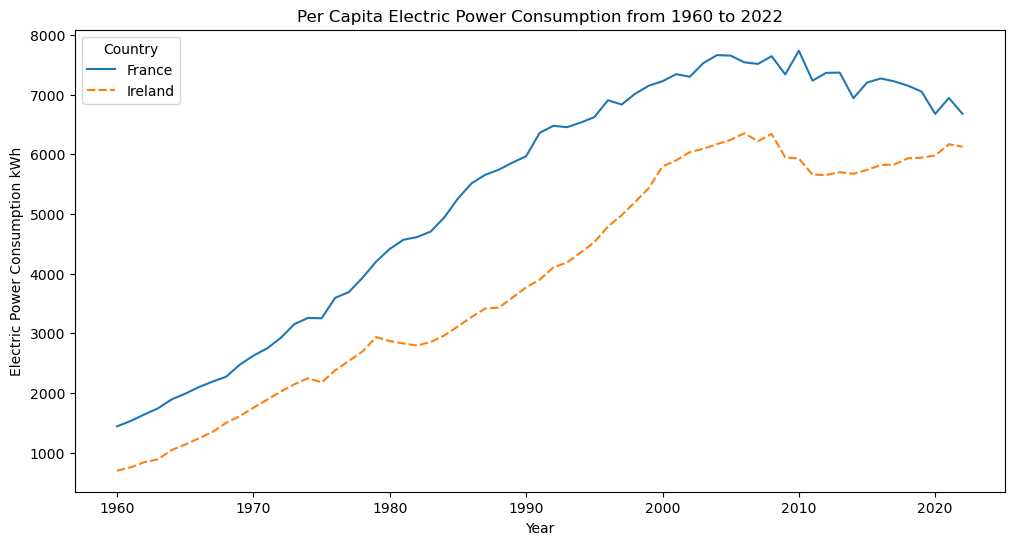

In [267]:
filtered_data = past_recent_long[past_recent_long['Country Name'].isin(['Ireland', 'France'])]

# Time series plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data, x='Year', y='Electric Power Consumption', hue= 'Country Name', style = 'Country Name')
plt.title('Per Capita Electric Power Consumption from 1960 to 2022')
plt.xlabel('Year')
plt.ylabel('Electric Power Consumption kWh')
plt.legend(title='Country')
plt.show()

#### **Interpretation**: 

The graph shows the annual electricity consumption France and Ireland from 1960 to 2022. The electricity consumption trends are similar in both countries. The figures gradually increased year-on-year and begins to decline after 2010 and remained steady in 2020.

Electricity consumption in Ireland: The electricity consumption in Ireland began with just below 1000 kWh in 1960. It rose to nearly 2500 kWh after two decades. The amount steadily increased annually until it reached its highest peak around 6000 kWh in 2010. There was a dip in 2010 and the consumption remained fluctuated around 6000 kWh.

Electricity consumption in Ireland: The electricity consumption in France started at 1500 KwH in 1960. The figure inclined to nearly 6000 kWh in 1990. The consumption reached highest point 7800 kWh in 2010. The consumption went down gradually to 7000 and fluctuated around 7000 towards the end of 2022.

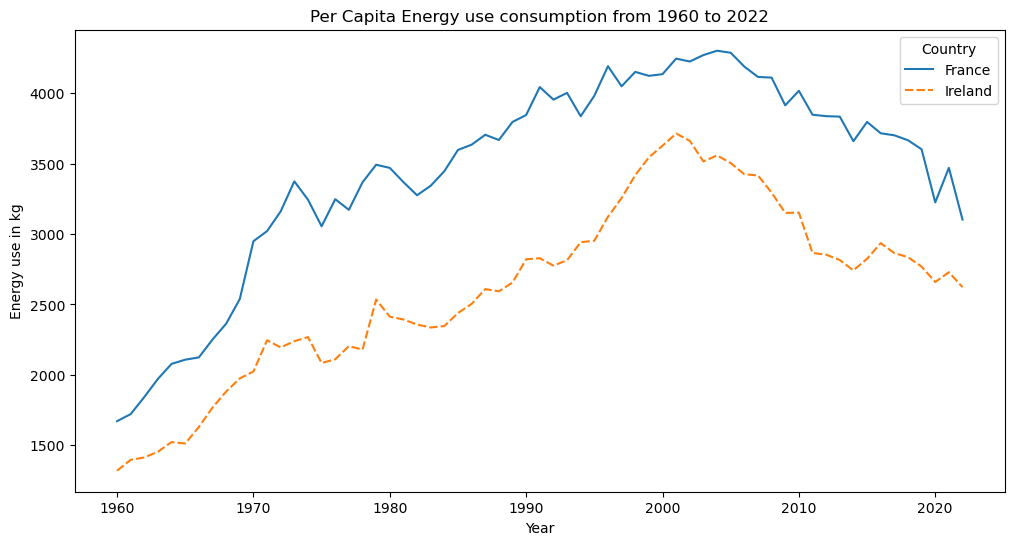

In [269]:
filtered_data = past_recent_long[past_recent_long['Country Name'].isin(['Ireland', 'France'])]

# Time series plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data, x='Year', y='Energy use', hue= 'Country Name', style = 'Country Name')
plt.title('Per Capita Energy use consumption from 1960 to 2022')
plt.xlabel('Year')
plt.ylabel('Energy use in kg')
plt.legend(title='Country')
plt.show()

#### **Interpretation**: 

The graph shows the annual energy use of France and Ireland from 1960 to 2022. Both countries follows similar trends in energy usage. The figures gradually increased year-on-year and begins to decline after 2000. The highest peak in usuage can be observed around 2000. 

Energy use in Ireland: The energy use in Ireland begins with just below 1500 kg in 1960. It rose to nearly 2500 kg after two decades. The amount steadily increased annually until it reached its highest peak around 3700 kg in 2000. However, the oil dependence in energy use has slowly declined afterward and droppted to nearly 2600 kg beyond 2020. 

Energy use in France: The energy use in France begins with just around 1700 kg in 1960. The oil usage increased to above 4000 kg in 1990 and it skyrocketed to nearly 4500 in 2005. The figure went down siginificantly to 3500 kg in 3500 kg. 

### Visulaizing graphs: Plotting histograms

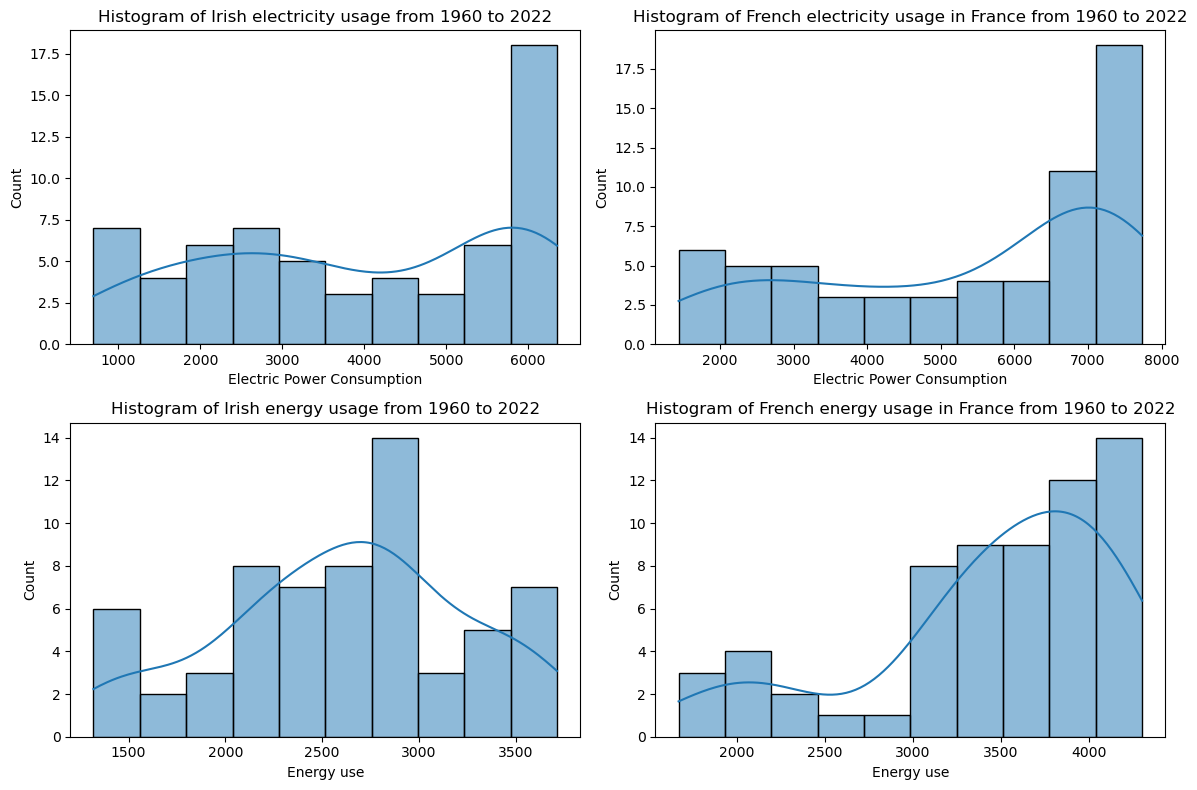

In [272]:
fig, axes = plt.subplots(2, 2,  figsize=(12, 8))

sns.histplot(Ireland_data['Electric Power Consumption'], kde=True, bins = 10, ax=axes[0,0])
axes[0,0].set_title('Histogram of Irish electricity usage from 1960 to 2022')

sns.histplot(France_data['Electric Power Consumption'], kde=True, bins = 10, ax=axes[0,1])
axes[0,1].set_title('Histogram of French electricity usage in France from 1960 to 2022')

sns.histplot(Ireland_data['Energy use'], kde=True, bins = 10, ax=axes[1,0])
axes[1,0].set_title('Histogram of Irish energy usage from 1960 to 2022')

sns.histplot(France_data['Energy use'], kde=True, bins = 10, ax=axes[1,1])
axes[1,1].set_title('Histogram of French energy usage in France from 1960 to 2022')

plt.tight_layout()
plt.savefig('histograms_IE_FR.png')
plt.show()

#### **Interpretation**: 

Electric Power distribution of Ireland: The data is slightly negatively skewed to the left because the highest peak of values are clustered around 6000 kWh. 
The frequecy of values is lowest between 4000 and 5000 kWh. The higher values are pulling the distribution to left-skewness. 

Electricity distribution of France: The data is negatively skewed to the left because the highest peak is observed at 8000 kWh. The second highest observed common occurance is clustered around 7000 kWh. The frequency of values is lowest between the range of 4000 and 5000 kWh. The second lowest can be found within the range 6000 kWh. 

Energy use distribution of Ireland: The distribution is slightly similar to normal distribution since no outliers are observed in the dataset. Additionally, the standard deviation 626 is lowest among the entire dataset. The highest frequency of values are observed within 2500 and 3000 kg. The range between 1500 and 2000 kg are least commonly observed data point. The second lowest observed value fell between 3000 and 3500 kg.

Energy use distribution of France: The distribution is left-skewed. The higher values are clustered around 3000 and 4000 kg and beyond, making distribution negatively skewed due to the presence of outliers. The least commonly found values lied between 2500 and 3000 kg. The highest frequency of values are observed around 4000 kg. The second high frequncy of values fell between 3000 and 4000 kg. 

### Visulaizing graphs: Boxplot

#### **Interpretation**: 

The boxplot compares France and Ireland's annual electric power consumption from 1960 to 2022.

Boxplot of electricity consumption in France: The lower bound of consumption can be found at 1500 kWh. 25th percentile of data can be seen at 3400. 50th percentile of data falls at 6400 which is close to 75th percentile of data. This means that the distribution is left-skewed. 

Boxplot of electricity consumption in Ireland: The lower bound of consumption is 800 kWh. The 25th percentile of data is 2300 kWh, and the 50th percentile is 4200 kWh. The distribution is slightly left-skewed. 

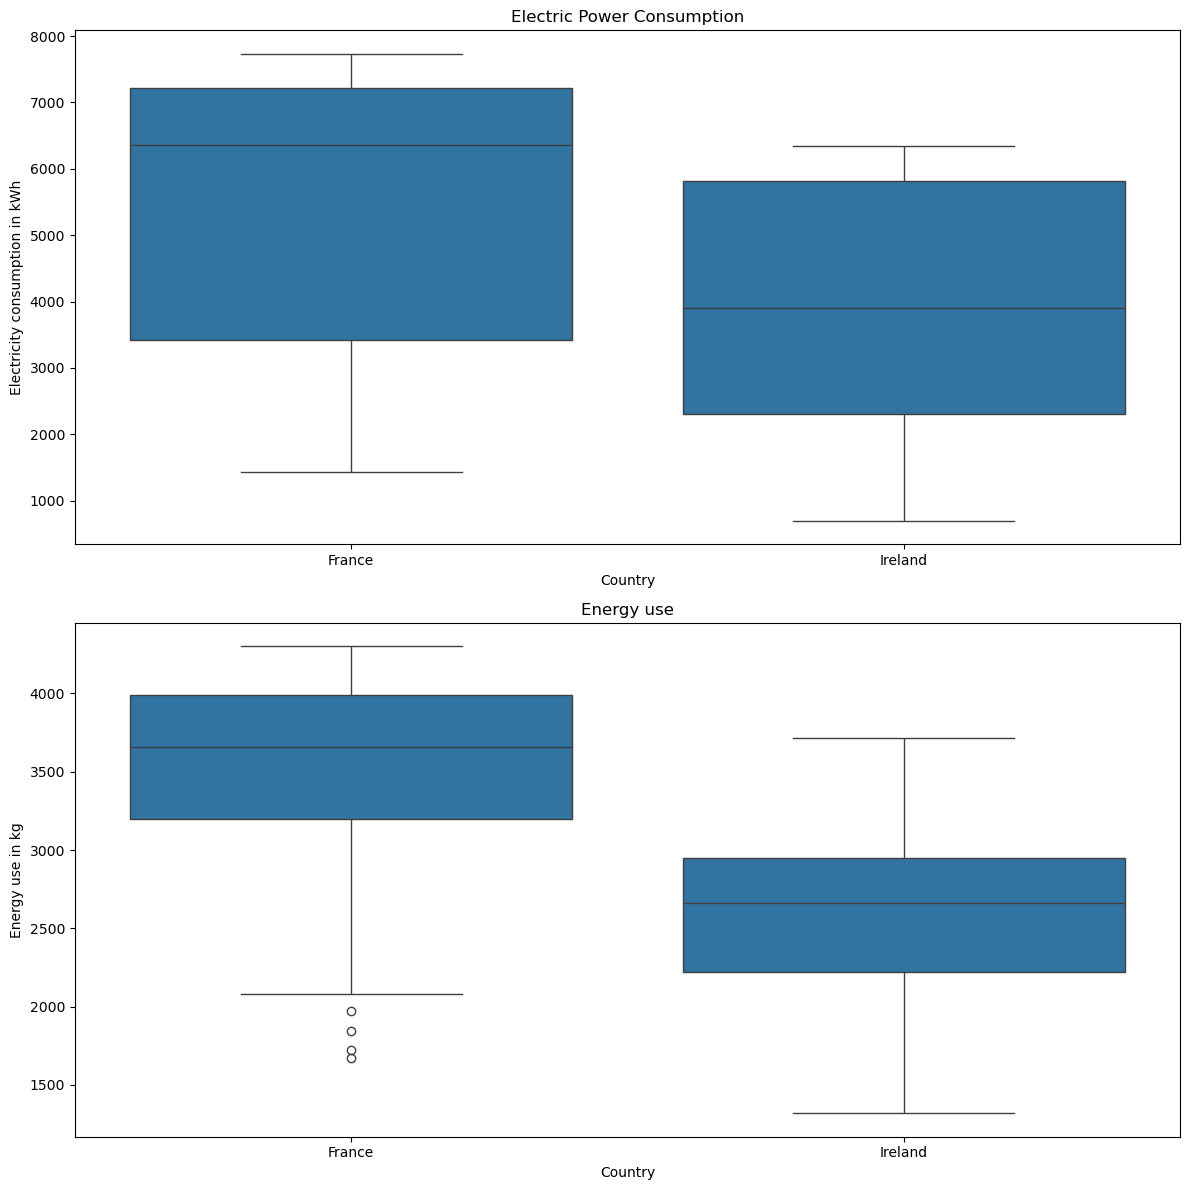

In [276]:
# Box plot
IE_FR_data = past_recent_long[past_recent_long['Country Name'].isin(['Ireland', 'France'])]

fig, axes = plt.subplots(2,1, figsize=(12, 12))
sns.boxplot(data=IE_FR_data, x='Country Name', y='Electric Power Consumption', ax=axes[0])
axes[0].set_title('Electric Power Consumption')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Electricity consumption in kWh')

sns.boxplot(data=IE_FR_data, x='Country Name', y='Energy use', ax=axes[1])
axes[1].set_title('Energy use')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Energy use in kg')
plt.tight_layout()
plt.show()

**Interpretation**: 

Electric Power consumption in France: 50th percentile of data is in 6500 kWh approximately. 75th percentile of data falls in the range between 7000 and 7300. The maximum threshold can be seen around 7500, whereas the minimum threshold exists around 1500 kWh. The median, 50th percentile slightly close to 75th percentile, the spread of data remain slightly left-skewed.

Electric Power consumption in Ireland: 50th percentile of the data just over 4000 kWh. The lower bound of the data is approximately 650 kWh, while the upper bound is 6500 kWh. The distribution is slightly positively-skewed, the median is closer to the 25th percentile, 

Energy use in France: 50th percentile of data is in 3700 kg approximately. 75th percentile of data falls around 4000 kg. The maximum threshold can be seen around 4500, whereas the minimum threshold exists around 2100 kg. The median, 50th percentile slightly close to 75th percentile, the spread of data remain slightly left-skewed.

Energy use in Ireland: 50th percentile of the data is approximately around 2700kg. The lower bound of the data is approximately 1000 kg, while the upper bound is just over 3000. The distribution is slightly negatively-skewed, since the median is closer to the 75th percentile.

**Key observations**:

The box plot shows that Francec has a higher median electricity consumption and energy use than and a wider interquartile range compared to the Republic of Ireland in electricity consumption. The IQR of both dataset are relatively similar in the energy use variable. 

### Visulaizing graphs: Checking normality with QQ plot

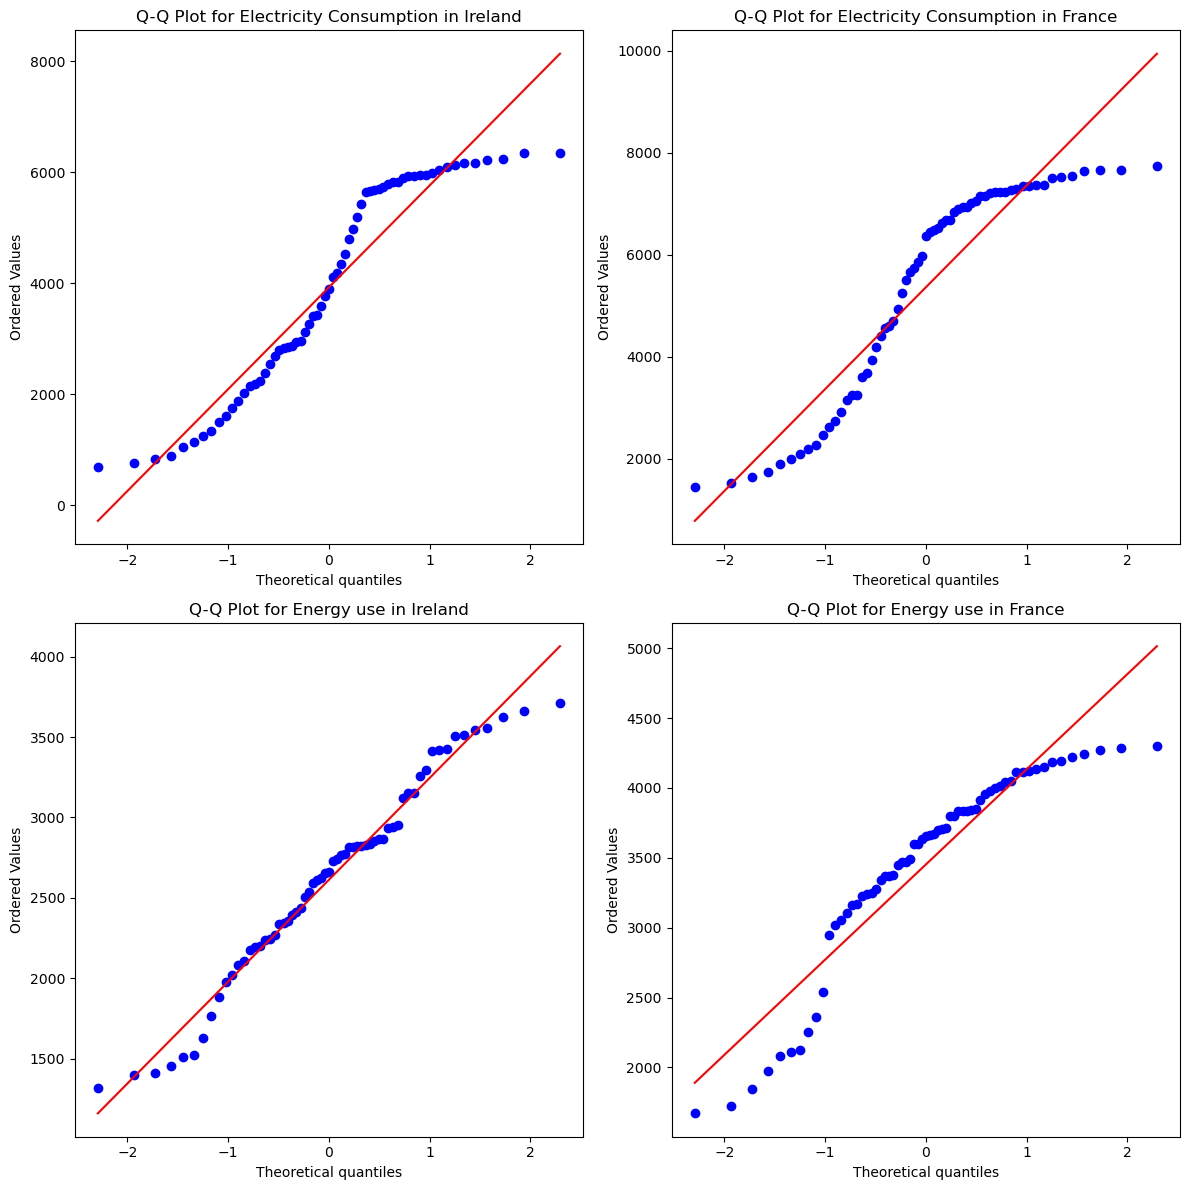

In [279]:
plt.figure(figsize=(12, 12))

Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland'][['Electric Power Consumption', 'Energy use']]
France_data = past_recent_long[past_recent_long['Country Name'] == 'France'][['Electric Power Consumption', 'Energy use']]

plt.subplot(2,2,1)
stats.probplot(Ireland_data ['Electric Power Consumption'], plot=plt)
plt.title("Q-Q Plot for Electricity Consumption in Ireland")

plt.subplot(2,2,2)
stats.probplot(France_data['Electric Power Consumption'], plot=plt)
plt.title("Q-Q Plot for Electricity Consumption in France")

plt.subplot(2,2,3)
stats.probplot(Ireland_data ['Energy use'], plot=plt)
plt.title("Q-Q Plot for Energy use in Ireland")

plt.subplot(2,2,4)
stats.probplot(France_data['Energy use'], plot=plt)
plt.title("Q-Q Plot for Energy use in France")

plt.tight_layout()
plt.savefig('QQplots.png')
plt.show()

#### **Interpretation**: 

Before machine learning, the feature should be checked to see whether the data points in the dataset passed the normality check or not. The normality check can be conducted by using a Q-Q plot. 

QQ-Plot for Electricity Consumption in Ireland: The data points are far away from the theoretical quartile of normal distribution. The data points met with the points of theoretical quartile at 0,-2, and 1. The remaining data points are away from the points of normally distributed data. This means the influence of extreme values is affecting the distribution of data. 

QQ-Plot for Energy use in Ireland: The numerous data points are close to the theoretical quartile of normal distribution. The data points met with the points of theoretical quartile from -1 to 1 and at 1.5. The remaining data points are away from the points of normally distributed data. The slight S-shape in the chart tells that the data is not normally distributed. 

QQ-Plot for Electricity Consumption in France: Data points are far away from the theoretical quartile. The data points intercepts at -2,-0.5, and 1. The remaining data points are away from the normal distribution. The data is not normally distributed data.

QQ-Plot for Energy use in France: The data points are far away from the theoretical quartile of normal distribution. The data points met with the points of theoretical quartile at 1. The remaining data points are away from the points of normally distributed data.

### Checking normality using Shapiro test

In [282]:
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland'][['Energy use']]

print("Shapiro-Wilk Test for 'Energy use in Ireland'")
shap_stat, shap_p = shapiro(Ireland_data)
print(f"Statistic = {shap_stat:.4f}, p-value = {shap_p:.4f}")
if shap_p < 0.05:
    print("→ Reject H₀: Data is NOT normally distributed\n")
else:
    print("→ Accept H₀: Data is normally distributed\n")

Shapiro-Wilk Test for 'Energy use in Ireland'
Statistic = 0.9694, p-value = 0.1185
→ Accept H₀: Data is normally distributed



**Interpretation:**

Shapiro test is performed to check the distribution. When test statistic value is equal to 11, it assumes that the data follows normality. As test-statistics is 0.96, the data is moderately following a normal distribution. 

The null hypothesis is the data is normally distributed, whereas the alternative hypothesis is that the data is not normally distributed. 

As p-value is below 0.1185, the test rejects the alternative hypothesis and accepts the null hypothesis. The data is normally distributed.

In [284]:
France_data = past_recent_long[past_recent_long['Country Name'] == 'France'][['Energy use']]

print("Shapiro-Wilk Test for 'Energy use in France'")
shap_stat, shap_p = shapiro(France_data)
print(f"Statistic = {shap_stat:.4f}, p-value = {shap_p:.4f}")
if shap_p < 0.05:
    print("→ Reject H₀: Data is NOT normally distributed\n")
else:
    print("→ Accept H₀: Data is normally distributed\n")

Shapiro-Wilk Test for 'Energy use in France'
Statistic = 0.8790, p-value = 0.0000
→ Reject H₀: Data is NOT normally distributed



**Interpretation:**


When test statistic value is equal to 1, it assumes that the data follows normality. As test-statistics is 0.87, the data is not following normal distribution. 

As p-value is below 0.00, the test rejects the null hypothesis and accepts alternative hypothesis which says that data is not normally distributed. Since data is not in the normal distribution, non-parametric hypothesis test should be performed for the dataset. 

### Confidence Interval

**Problem statement:**

The analysis aim to compare a range of confidence of two different countries such as Ireland and France. We want to check if there is overlaps in confidence intervals between two groups to check if the two groups is statistically significant.

This analysis uses inferential statistics to compare population mean electric power consumption in Ireland and France, providing insights into their average energy consumption levels.

In [288]:
# Filter Ireland and France
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland']['Electric Power Consumption']
France_data = past_recent_long[past_recent_long['Country Name'] == 'France']['Electric Power Consumption']

# Calculate confidence intervals
confidence_level = 0.95
def ci(data):
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    margin_error = std_err * stats.t.ppf((1 + confidence_level) / 2, n - 1)
    ci_lower = mean - margin_error
    ci_upper = mean + margin_error
    return mean, ci_lower, ci_upper

# Confidence intervals for Ireland
print('Confidence Interval for Electric Power Consumption')
mean_ie, ci_lower_ie, ci_upper_ie = ci(Ireland_data.values)
print(f"Ireland: \n Mean = {mean_ie}")
print(f"Confidence level: {confidence_level}")
print(f"CI = ({ci_lower_ie}, {ci_upper_ie})")

# Confidence intervals for France
mean_fr, ci_lower_fr, ci_upper_fr = ci(France_data.values)
print(f"France: \n Mean = {mean_fr}")
print(f"Confidence level: {confidence_level}")
print(f"CI =({ci_lower_fr}, {ci_upper_fr})")

Confidence Interval for Electric Power Consumption
Ireland: 
 Mean = 3926.817692134023
Confidence level: 0.95
CI = (3452.8688208862027, 4400.766563381843)
France: 
 Mean = 5361.112423174042
Confidence level: 0.95
CI =(4835.566564964188, 5886.658281383897)


**Interpretation**:

+ Mean Values:

     + The mean value represents the average of the data points collected from the samples. For Ireland, the mean is approximately 3926. The mean value for France is 5361.

      
+ 95% Confidence Interval:
  
    + 95% confidence level is used to express the uncertainty of the estimation process. Technically, 95% confidence means that if we take repeated random samples from a population, and construct a confidence interval for each sample using the same method, we can expect that 95% of these intervals will capture the actual population mean and 5% of the total will not capture the population mean([Robert,2006](https://www.sciencedirect.com/topics/mathematics/confidence-interval)).
      
+ CI = (3452.8688208862027, 4400.766563381843) for Irleand
    + 95% of the interval between 3452.87 and 4400.77 will capture the actual population mean

+ CI =(4835.566564964188, 5886.658281383897) for France
    + 95% of the interval between 4835.57 and 5886.66 will capture the actual population mean. 

Comparision: 

+ The average electricity consumption of France is 36% higher in France than Ireland. Since France's lower bound of electricity consumption is greater than Ireland's electricity consumption, it can be concluded that France electricity consumption is higher than Ireland. Since the confidence intervals do not overlap each other, both groups have statistical significance. 

**Problem statement:**

The analysis aim to compare a range of confidence of two different countries such as Ireland and France. We want to check if there is overlaps in confidence intervals between two groups to check if the two groups is statistically significant.

This analysis uses inferential statistics to compare population mean energy use in Ireland and France, providing insights into their average energy consumption levels.


In [291]:
# Filter Ireland and France
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland']['Energy use']
France_data = past_recent_long[past_recent_long['Country Name'] == 'France']['Energy use']

# Calculate confidence intervals
confidence_level = 0.95
def ci(data):
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    margin_error = std_err * stats.t.ppf((1 + confidence_level) / 2, n - 1)
    ci_lower = mean - margin_error
    ci_upper = mean + margin_error
    return mean, ci_lower, ci_upper

# Confidence intervals for Ireland
print('Confidence Interval for Energy use')
mean_ie, ci_lower_ie, ci_upper_ie = ci(Ireland_data.values)
print(f"Ireland: \n Mean = {mean_ie}")
print(f"Confidence level: {confidence_level}")
print(f"CI = ({ci_lower_ie}, {ci_upper_ie})")

# Confidence intervals for France
mean_fr, ci_lower_fr, ci_upper_fr = ci(France_data.values)
print(f"France: \n Mean = {mean_fr}")
print(f"Confidence level: {confidence_level}")
print(f"CI =({ci_lower_fr}, {ci_upper_fr})")

Confidence Interval for Energy use
Ireland: 
 Mean = 2612.552332014757
Confidence level: 0.95
CI = (2454.7139780807524, 2770.390685948762)
France: 
 Mean = 3452.168393309429
Confidence level: 0.95
CI =(3273.744362687234, 3630.592423931624)


**Interpretation**:

+ Mean Values:
    + The mean value represents the average of the data points collected from the samples. For Ireland, the mean is approximately 2612. The mean value for France is 3452.
      
+ 95% Confidence Interval:
  
    + 95% confidence level is used to express the uncertainty of the estimation process. Technically, 95% confidence means that if we take repeated random samples from a population, and construct a confidence interval for each sample using the same method, we can expect that 95% of these intervals will capture the population mean and 5% of the total will not capture the population mean.
      
+ CI = (2454.7139780807524, 2770.390685948762) for Irleand
    + 95% interval between 3452.87 and 4400.77 will capture the actual population mean

+ CI =(4835.566564964188, 5886.658281383897) for France
    + 95% interval between 3273.74 and 3630.59 will capture the actual population mean. 

Comparision: 

+ The average energy use of France is 32% higher in France than Ireland. Since France's lower bound of energy use is greater than Ireland, it can be concluded that France energy use is higher than Ireland. Since the confidence intervals do not overlap each other, both groups have statistical significance. 

# Hypothesis Testing

### Following hypothesis testing are performed: 

+ Shapiro
+ Mann-Whitney U Test
+ T-test
+ Kruskal-Wallis Test (Non-parametric test)
+ Chi Square
+ Adfuller Test

## 1. Shapiro-Wilk Test of Normality

Shapiro-Wilk Test of Normality tests are one way to assess whether a data set is approximately distributed along a normal distribution curve([Lincoln University,n.d](https://guides.library.lincoln.ac.uk/mash/statstest/shapiro-wilk)).

**Problem statement:**

A data analyst wants to carry out the parametric tests on the electric power consumption data in Ireland. However, the parametric tests require a normality assumption in the data. Therefore, the Shapiro-Wilk Test of Normality is conducted to determine whether the parametric test, such as t-test, Z test can be performed or not.

In [297]:
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland'][['Electric Power Consumption']]

print("Shapiro-Wilk Test for 'Electric Power Consumption in Ireland'")
shap_stat, shap_p = shapiro(Ireland_data)
print(f"Statistic = {shap_stat:.4f}, p-value = {shap_p:.4f}")
if shap_p < 0.05:
    print("→ Reject H₀: Data is NOT normally distributed\n")
else:
    print("→ Accept H₀: Data is normally distributed\n")

Shapiro-Wilk Test for 'Electric Power Consumption in Ireland'
Statistic = 0.8975, p-value = 0.0001
→ Reject H₀: Data is NOT normally distributed



**Interpretation:**

The null hypothesis is the data is normally distributed, whereas the alternative hypothesis is that the data is not normally distributed. 

As test statistic value is equal to 0.897, it assumes that the data is slightly following normality. As p-value is 0.0001 which is below 0.05 threshold, the test rejects the null hypothesis and accepts the alternative hypothesis. The data is not normally distributed.

The normality test has shown that the data has characteristics that are very unlikely to occur data actually came from a normal distribution. Therefore, we can say that data is not normally distributed and non-parametric statistical tests should be performed or applying transformations to data to achieve normality in the data.


In [299]:
France_data = past_recent_long[past_recent_long['Country Name'] == 'France'][['Electric Power Consumption']]

print("Shapiro-Wilk Test for 'Electric Power Consumption in France'")
shap_stat, shap_p = shapiro(France_data)
print(f"Statistic = {shap_stat:.4f}, p-value = {shap_p:.4f}")
if shap_p < 0.05:
    print("→ Reject H₀: Data is NOT normally distributed\n")
else:
    print("→ Accept H₀: Data is normally distributed\n")

Shapiro-Wilk Test for 'Electric Power Consumption in France'
Statistic = 0.8652, p-value = 0.0000
→ Reject H₀: Data is NOT normally distributed



**Interpretation:**

The null hypothesis is the data is normally distributed, whereas the alternative hypothesis is that the data is not normally distributed. 

As test statistic value is equal to 0.865, it assumes that the data is slightly following normality. As p-value is 0.0000, which is below 0.05 threshold and strongly rejecting null hypothesis. Therefore, the data is not normally distributed.

The normality test has shown that the data have characteristics that are very unlikely to occur data came from a normal distribution. Therefore, we can say that data is not normally distributed and non-parametric statistical tests should be performed or transformations to the data to achieve normality in the data.

### 2. Mann-Whitney U Test (Non-parametric test)

**Problem statement:**

Is there a statistically significant difference in the distribution of Per capita electric power consumption between Ireland and France?"

The reason for conducting the Mann-Whitney U Test is that the data does not follow the normality and non-parametric test should be performed.

The Mann-Whitney U test is thus the non-parametric counterpart to the t-test for independent samples; it is subject to less stringent assumptions than the t-test. Therefore, the Mann-Whitney U test is always used when the requirement of normal distribution for the t-test is not met source: https://datatab.net/tutorial/mann-whitney-u-test. 

Mann-Whitney U Test is used to test whether there is a difference between two independent samples, whereas t-test tests two independent samples to identify if there is mean difference between two groups. Two independent samples in the data are the electricity consumption data of Ireland and France. Since both data are in non-normal distribution, Mann-Whitney U Test is performed in this project.

Hypothesis testing: 

+ H₀ Null Hypothesis: There is no significant difference between median value of Ireland's electricity consumption and of France's electricity consumption.
+ Alternative Hypothesis: There is a significant difference between median value of Ireland's electricity consumption and of France's electricity consumption.

In [303]:
# Separate data for Ireland and France
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland']['Electric Power Consumption']
France_data = past_recent_long[past_recent_long['Country Name'] == 'France']['Electric Power Consumption']

# Perform the Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(Ireland_data.values, France_data.values, alternative='less')

print(f"Mann-Whitney U statistic: {u_stat}, p-value: {p_value}")
print("3. Mann-Whitney U Test (Ireland vs France - Per Capita Electric Power Consumption)")

#assessing statistical significance
if p_value < 0.05:
    print("→ Reject H₀: median differs between two countries\n")
else:
    print("→ Fail to reject H₀: No significant difference between two countries\n")

Mann-Whitney U statistic: 1122.0, p-value: 1.3004189220482906e-05
3. Mann-Whitney U Test (Ireland vs France - Per Capita Electric Power Consumption)
→ Reject H₀: median differs between two countries



**Interpretation of results:**

Mann-Whitney U statistic result (1122) is the result of calculating the rank sum difference of two sample groups by sorting all data points from smallest to largest values. 

p-value (1.3004189220482906e-05) equavialent to 0.000013 means that strongly rejecting null hypothesis. There is highly statistical significance between the median value between Ireland and France electric power consumption. 

For a given dataset, Mann-Whitney U test showed that the difference between Ireland and France with respect to dependent variable, electric power consumption differs signifincantly in median rank for each group. Thus, null hypothesis is rejected and the difference does not happen by chance.

In [305]:
# Separate data for Ireland and France
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland']['Energy use']
France_data = past_recent_long[past_recent_long['Country Name'] == 'France']['Energy use']

# Perform the Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(Ireland_data.values, France_data.values, alternative='less')

print(f"Mann-Whitney U statistic: {u_stat}, p-value: {p_value}")
print("3. Mann-Whitney U Test (Ireland vs France - Per Capita Energy use")

#assessing statistical significance
if p_value < 0.05:
    print("→ Reject H₀: median differs between two countries\n")
else:
    print("→ Fail to reject H₀: No significant difference between two countries\n")

Mann-Whitney U statistic: 710.0, p-value: 2.5483981394782406e-10
3. Mann-Whitney U Test (Ireland vs France - Per Capita Energy use
→ Reject H₀: median differs between two countries



**Interpretation of results:**

Mann-Whitney U statistic result (720) is the result of calculating the rank sum difference of two sample groups by sorting all data points from smallest to largest values. 

p-value (2.5483981394782406e-10) equavialent to 0.000000000254 means that strongly rejecting null hypothesis. There is highly statistical significance between the median value between Ireland and France energy use. 

For a given dataset, Mann-Whitney U test showed that the difference between Ireland and France with respect to dependent variable,  energy use betwen two countries differs signifincantly. Thus, null hypothesis is rejected and difference does not occur by chance. 

In [307]:
# Separate data for Electric Power Consumption and Energy use
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland']['Electric Power Consumption']
France_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland']['Energy use']

# Perform the Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(Ireland_data.values, France_data.values, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat}, p-value: {p_value}")
print("3. Mann-Whitney U Test (Electricity consumption vs Energy use in Ireland")

#assessing statistical significance
if p_value < 0.05:
    print("→ Reject H₀: median differs between two variables\n")
else:
    print("→ Fail to reject H₀: No significant difference between two variables\n")

Mann-Whitney U statistic: 2766.0, p-value: 0.00013860097065429574
3. Mann-Whitney U Test (Electricity consumption vs Energy use in Ireland
→ Reject H₀: median differs between two variables



**Interpretation of results:**

Mann-Whitney U statistic result (2766) is the result of calculating the rank sum difference of two sample groups by sorting all data points from smallest to largest values.

p-value (0.00013860097065429574) is below 0.05,  means that strongly rejecting null hypothesis. There is highly statistical significance between the median value between electric power consumption and energy use dataset of Ireland.

For a given dataset, Mann-Whitney U test showed that the difference between two dataset. Thus, null hypothesis is rejected and difference does not occur by chance.


### 3. Sample t-test (Paramateric test)

**Problem Statement:**

Is there a statistically significant difference in the average Electric Power Consumption between two independent groups, Ireland and France? 

This project perform sample t-test to see whether there is a difference in mean value between two groups. Average electricity consumption between Ireland and France dataset is performed to see whether the distributions are statistically significant or not. 
Average
The requirement before performing t-test: 

+ Dataset should follow normality
+ Observations are independent of each other
+ Dependent variables are contininous

Since all requirements are fulfilled except for the normality, the dataset should be transformed to acheive normality in the dataset. 

### johnsonsb transformation

After applying log, square root and cube root transformation, johnsonsb transformation acheives the closest to the normal distribution for electric power consumption data for Ireland and France. Johnsonsb Transformation is carried out to perform the t-test. 

Johnson SB Transformation is suitable for bounded data. For example, scores on a test with a fixed scores between 1 and 100, the underlying distribution of possible scores is bounded.

Although electric power consumption is not strictly bounded in real world, the dataset of Ireland and France over the observed period has naturally stayed within a bounded range.  The SB transformation is a better transformation for modeling the shape within that observed range and mapping it to normality.

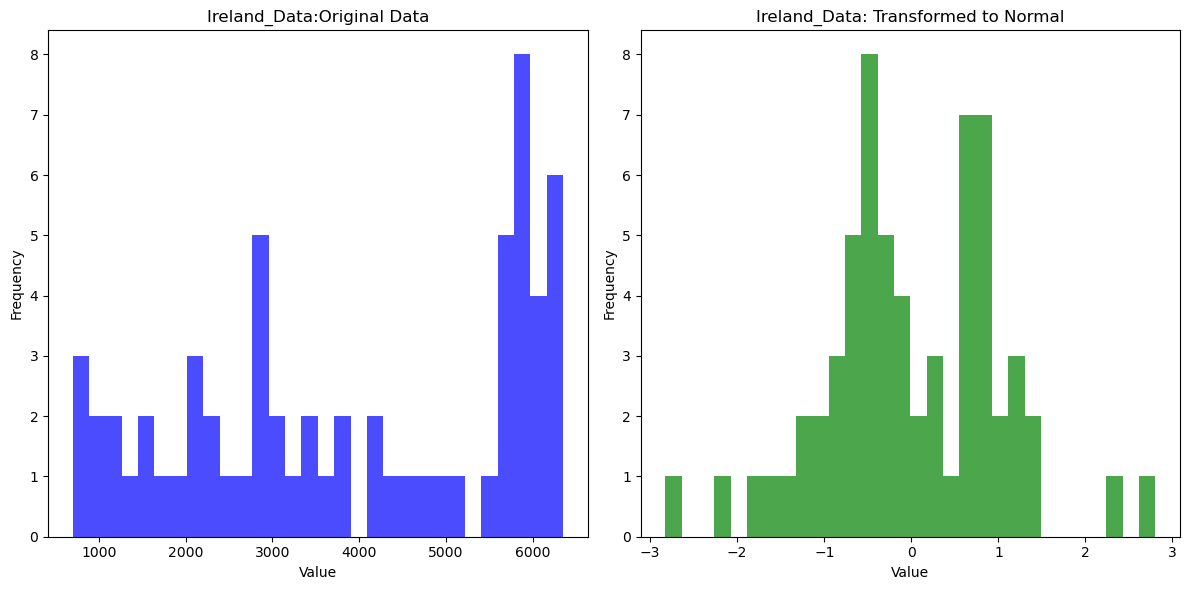

In [312]:
Ireland = past_recent_long[past_recent_long['Country Name'] == 'Ireland'][['Electric Power Consumption']]

# Fit the Johnson-SB distribution to the data
params = johnsonsb.fit(Ireland)

# Apply the CDF to your data (this gives cumulative probabilities)
cdf_values = johnsonsb.cdf(Ireland, *params)

# Apply the inverse of the normal CDF (ppf) to map it to a normal distribution
# Use the normal ppf to transform the cumulative probabilities to a normal distribution
normal_transformed_data = norm.ppf(cdf_values)

ie_normalized_data = (normal_transformed_data - np.mean(normal_transformed_data)) / np.std(normal_transformed_data)

# Visualize the original data and the transformed data
plt.figure(figsize=(12, 6))

# Original Data
plt.subplot(1, 2, 1)
plt.hist(Ireland, bins=30, alpha=0.7, color='blue', label='Original Data')
plt.title('Ireland_Data:Original Data')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Transformed Data
plt.subplot(1, 2, 2)
plt.hist(ie_normalized_data, bins=30, alpha=0.7, color='green', label='Transformed Data')
plt.title('Ireland_Data: Transformed to Normal')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('Johnsonsb_IE.png')
plt.show()


**Interpretation:**

Johnson-SB transformation is applied for bounded data. 
First, the data is fitted into the cumulative distribution function (CDF) for each data point based on the fitted Johnson SB distribution.
It is a crucial step to change raw data into a uniform probability to put the value between 0 and 1. 

Next, the inverse probability of CDF is applied which is the percent point function (PPF). It stretches probabilities into a normal shape. The reason for doing this is to make data follow a normal distribution and enable parametric tests (e.g., t-tests) that assume normality. Finally, data is standardised.

The original data of Ireland's electric power consumption data is slightly right-skewed. Applying t-test on the original data will be invalid if normality is violated.

After the data is fit into Johnson SB, the distribution is closer to normal. The normality check can be confirmed after conducting the Shapiro-Wilk Test. 

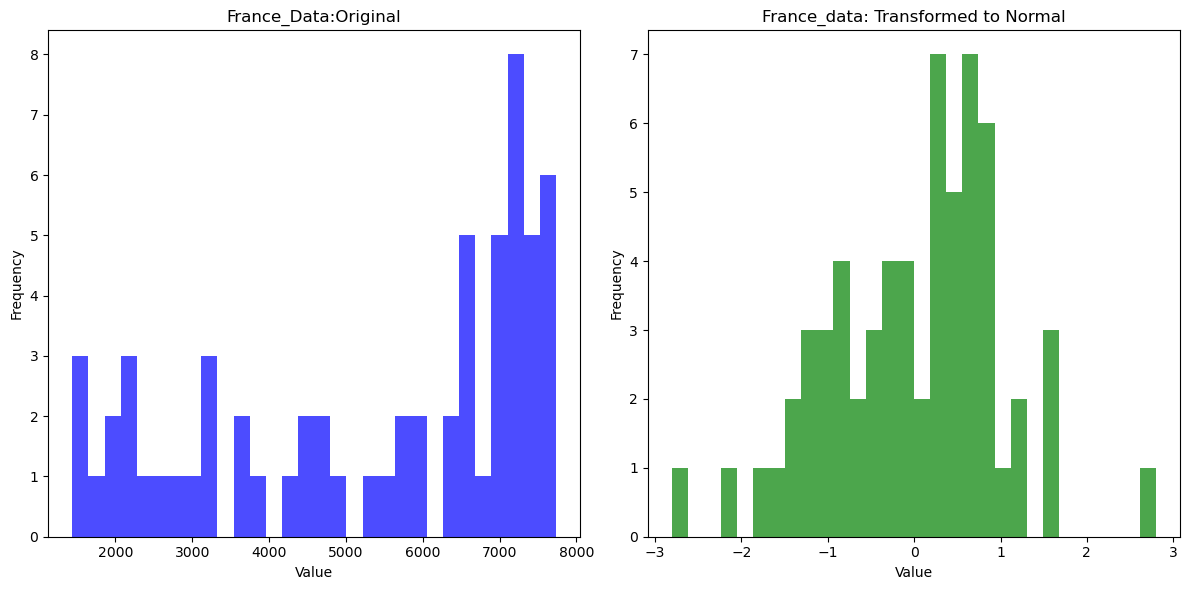

In [314]:
# Example: Create a skewed dataset
France_data = past_recent_long[past_recent_long['Country Name'] == 'France'][['Electric Power Consumption']]

# Fit the Johnson-SB distribution to the data
params = johnsonsb.fit(France_data)

# Apply the CDF to your data (this gives cumulative probabilities)
cdf_values = johnsonsb.cdf(France_data, *params)

# Apply the inverse of the normal CDF (ppf) to map it to a normal distribution
# Use the normal ppf to transform the cumulative probabilities to a normal distribution
normal_transformed_data = norm.ppf(cdf_values)

fr_normalized_data = (normal_transformed_data - np.mean(normal_transformed_data)) / np.std(normal_transformed_data)

# Visualize the original data and the transformed data
plt.figure(figsize=(12, 6))

# Original Data
plt.subplot(1, 2, 1)
plt.hist(France_data, bins=30, alpha=0.7, color='blue', label='Original Data')
plt.title('France_Data:Original')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Transform Data
plt.subplot(1, 2, 2)
plt.hist(fr_normalized_data, bins=30, alpha=0.7, color='green', label='Transformed Data')
plt.title('France_data: Transformed to Normal')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('Johnsonsb_fr.png')
plt.show()

**Interpretation:**

Johnson-SB transformation is applied for bounded data. 

The original data of France's electric power consumption data is slightly left-skewed. Applying a t-test on the original data will be invalid if normality is violated.

After the data is fit into Johnson SB, the distribution is closer to normal. The normality check can be confirmed after conducting the Shapiro-Wilk Test. 

In [316]:
print("Shapiro-Wilk Test for 'Electricity consumption'")
shap_stat, shap_p = shapiro(ie_normalized_data)
print(f"Statistic = {shap_stat:.4f}, p-value = {shap_p:.4f}")
if shap_p < 0.05:
    print("→ Reject H₀: Data is NOT normally distributed\n")
else:
    print("→ Accept H₀: Data is normally distributed\n")

Shapiro-Wilk Test for 'Electricity consumption'
Statistic = 0.9832, p-value = 0.5464
→ Accept H₀: Data is normally distributed



**Interpretation:**

After transformation, Shapiro-Wilk Test for normality is accepting the null-hypothesis. P-value is 0.54, which is greater than the 0.05 threshold.
The data is normally distributed and can apply t-test hypothesis testing on the dataset.

In [318]:
print("Shapiro-Wilk Test for 'Electricity consumption'")
shap_stat, shap_p = shapiro(fr_normalized_data)
print(f"Statistic = {shap_stat:.4f}, p-value = {shap_p:.4f}")
if shap_p < 0.05:
    print("→ Reject H₀: Data is NOT normally distributed\n")
else:
    print("→ Accept H₀: Data is normally distributed\n")

Shapiro-Wilk Test for 'Electricity consumption'
Statistic = 0.9820, p-value = 0.4871
→ Accept H₀: Data is normally distributed



**Interpretation:**

After transformation, Shapiro-Wilk Test for normality is accepting the null-hypothesis. P-value is 0.48, which is greater than the 0.05 threshold.
The data is normally distributed and can apply t-test hypothesis testing on the dataset.

### t-test

Hypothesis testing:

+ H₀ Null Hypothesis: There is no significant difference between mean value of Ireland and of France's electricity consumption.
+ Alternative Hypothesis: There is a significant difference between mean value of Ireland and France's electricity consumption.


In [321]:
#Perform t-test

t_stat, p_value_ttest = stats.ttest_ind(ie_normalized_data,fr_normalized_data, equal_var=False)

print(f"t-statistic: {t_stat[0]:.4f}, p-value (t-test): {p_value_ttest[0]:.4f}")
# Decision for t-test (using α = 0.05)
alpha = 0.05
if p_value_ttest < alpha:
    print("Reject the null hypothesis: There is a significant difference in the average electricity consumption between France and Ireland.")
else:
    print("Fail to the null hypothesis: There is no significant difference in the average electricity consumption between France and Ireland.")

t-statistic: 0.0000, p-value (t-test): 1.0000
Fail to the null hypothesis: There is no significant difference in the average electricity consumption between France and Ireland.


**Interpretation:** 

The t-statistic is zero which means that the difference between mean of two group is zero and mean of two groups have similar distribution.

High p-value indicates no significant difference between Ireland and France on transformed data. 
    
P values, equals to 1 suggests there is no statistical difference between two groups, accepting null hypothesis strongly. 

The potential cause of similar mean and distribution is due to transformation. After transformation, two datasets are scaled to similar mean and standard deviation.


### 4. Kruskal-Wallis Test (Non-parametric test)

**Problem statement:**

Do two or more independent groups in Eu energy consumption dataset have statistically significant differences in their distributions of the variable of interest? Kruskal-Wallis Test is used to identify whether two or more groups have similar distributions or not. It is an alternative to ANOVA. 

The Kruskal–Wallis test is just the rank-sum test extended to more than two samples([Yinglin,2020](https://www.sciencedirect.com/topics/medicine-and-dentistry/kruskal-wallis-test)). The hypothesis testing is carried out since our data does not follow the normality assumption. 

Non-parametric Kruskal-Wallis test does not assume a normal distribution of the underlying data.
    
+ H₀ Null Hypothesis: the mean ranks of the groups are the same.
+ Alternative Hypothesis: There is a significant difference among the mean ranks of the groups are the same.



In [325]:
Ireland_data = past_recent_long[past_recent_long['Country Name'] == 'Ireland']['Energy use']
France_data = past_recent_long[past_recent_long['Country Name'] == 'France']['Energy use']
Germany_data = past_recent_long[past_recent_long['Country Name'] == 'Germany']['Energy use']

stat, p_value = kruskal(Ireland_data, France_data, Germany_data)

print(f"Kruskal-Wallis statistic: {stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: At least one country's mean rank sum of energy usage is different.")
else:
    print("Fail to reject the null hypothesis: No significant difference among countries.")

Kruskal-Wallis statistic: 70.915
P-value: 0.000
Reject the null hypothesis: At least one country's mean rank sum of energy usage is different.


**Interpretation:**

A higher Kruskal-Wallis statistic, the bigger difference in the mean rank sum among. (70.915) test statistics suggests that there is substantial differences among three countries.

P-value, close to 0 is strongly rejects null hypothesis. The differences do not occur by chance. 

### 5. Chi Square Test

**Problem statement:**

The test is conducted to see if there is a significant relationship between Ireland and France. Non-parametric Chi-Square Test determines whether there is an association between categorical variables (i.e., whether the variables are independent or related).

In [328]:
filtered_data = past_recent_long[past_recent_long['Country Name'].isin(['Ireland', 'France'])]

print(f"max: {filtered_data['Energy use'].max()}")
print(f"mean: {filtered_data['Energy use'].mean()}")
print(f"median: {filtered_data['Energy use'].median()}")
print(f"min: {filtered_data['Energy use'].min()}")

max: 4301.552485163359
mean: 3032.3603626620943
median: 3135.950374699429
min: 1318.812486742558


Bins are calculated adjusted based on the mininmum, maximum and mean of the energy use

+ H₀ Null Hypothesis: There is no association between the country (Ireland/France) and the categorized energy use levels
+ Alternative Hypothesis:  There is an association between the country (Ireland/France) and the categorized energy use levels

In [331]:
filtered_data = past_recent_long[past_recent_long['Country Name'].isin(['Ireland', 'France'])]

filtered_data['Energy_Category'] = pd.cut(
    past_recent_long['Energy use'],
    bins=[1000, 3000, 5000, float('inf')],
    labels=['Low', 'Medium', 'High']
)


# Then build the contingency table
contingency_table = pd.crosstab(filtered_data['Country Name'], filtered_data['Energy_Category'])

from scipy.stats import chi2_contingency, chi2

# Create contingency table
contingency_table = pd.crosstab(filtered_data['Country Name'], filtered_data['Energy use'])

# Perform Chi-Square test # Degrees of freedom = (rows - 1) * (columns - 1)
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Squared Test: Chi2-statistic = {chi2_stat}, p-value = {p_value_chi2}")

# Set significance level
alpha = 0.05
critical_value = chi2.ppf(1 - alpha, dof)  # <-- pass degrees of freedom, not the table

# Interpretation
if p_value_chi2 < alpha:
    result = f"Chi-Square Statistic: {chi2_stat}\nCritical Value: {critical_value}\np-value: {p_value_chi2}\nReject the null hypothesis: There is a significant relationship."
else:
    result = f"Chi-Square Statistic: {chi2_stat}\nCritical Value: {critical_value}\np-value: {p_value_chi2}\nFail to reject the null hypothesis: No significant relationship."

print(result)


Chi-Squared Test: Chi2-statistic = 126.0, p-value = 0.45809684713521515
Chi-Square Statistic: 126.0
Critical Value: 152.0938756919578
p-value: 0.45809684713521515
Fail to reject the null hypothesis: No significant relationship.


**Interpretation:**

Chi-square statistics result 126 is less than Critical value. Critical value is decision boundary which is used to accept or reject the null hypothesis. 

Since p-value is greater than 0.05, it fails to reject null hypothesis. There is no significant relationship between country categories such as Ireland and France and Energy use categories
    

### 6. Augmented Dickey-Fuller (ADF)

**Problem statement:**

A data analyst wants to conduct time series analysis and train machine learning model like ARIMA. The model requires to have stationary in the data. Stationary data assumes that statistical properties like mean and variance do not change over time. Therefore, the test needs to be performed to see whether the data should be differenced or not to achieve stable mean and variance.

In [334]:
filtered_df = past_recent_long[past_recent_long['Year'] >= 1990]

ireland = filtered_df[filtered_df['Country Name'] == 'Ireland']

# Assuming 'data' is your time series (e.g., Ireland's energy use)
result = adfuller(ireland['Energy use'])  
print('ADF Statistic:', result[0])  
print('p-value:', result[1])  
print('Critical Values:')  
for key, value in result[4].items():  
    print(f'{key}: {value}')  

# Interpret the result
if result[1] < 0.05:  
    print("Reject H₀: Data is stationary (no differencing needed)")  
else:  
    print("Fail to reject H₀: Data is non-stationary (differencing required)")  

ADF Statistic: -0.4795871985798494
p-value: 0.8959387391289917
Critical Values:
1%: -3.653519805908203
5%: -2.9572185644531253
10%: -2.6175881640625
Fail to reject H₀: Data is non-stationary (differencing required)


**Interpretation:**

ADF Statistic result is -0.4796. More negative values indicate stronger evidence against the presence of a unit root, which means more evidence for stationarity.

Since p-value is 0.8959 which is above 0.05 threshold is strongly accepting null hypothesis. Data is non-stationary data.  

Critical Values are threshold values from the Dickey-Fuller distribution at different significance levels (1%, 5%, and 10%). Critical values are compared against ADF statistic to make a decision about the null hypothesis.

    1%: -3.6535: At a 1% significance level, it would reject the null hypothesis if  ADF statistic is less than -3.6535.
    5%: -2.9572: At a 5% significance level, it would reject the null hypothesis if  ADF statistic is less than -2.9572.
    10%: -2.6176: At a 10% significance level, it would reject the null hypothesis if ADF statistic is less than -2.6176.

Since ADF test statistics is greater than all critical values, it fails to reject null hypothesis and data is not stationary.

In [336]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

import warnings 
warnings.filterwarnings('ignore')

In [337]:
df = pd.read_csv('eu_merged.csv')
df.head(2)

,Country Name,Country Code,Year,Electric Power Consumption,Energy use
0,Austria,AUT,1960,1814.676017,1546.261468
1,Austria,AUT,1961,1882.223711,1554.034906


### Autoregressive Integrated Moving Average (ARIMA)

This project will apply the Autoregressive Integrated Moving Average (ARIMA) model on the energy use of Ireland and Germany. 

Because ARIMA can predict the future trends based on the past observations([DataCampto,n.d](https://www.datacamp.com/tutorial/arima)) 

Before we applied ARIMA model, there are requirements we need to have in the data: 

+ A univariate time series (count or continuous) with at least 50-100 observations
+ If the time series consists of count data, the interval over which the count is taken must remain the same over time
+ If the time series consists of continuous data, the interval between measurements must remain the same over time
+ Data must be presented in a vertical vector (column of data) ([Columbia University Mailman School of Public Health,n.d](https://www.publichealth.columbia.edu/research/population-health-methods/box-jenkins-methodology)).

## Data Preparation for ARIMA 

In [340]:
# Filtering Ireland from original DF
ireland = df[df['Country Name'] == 'Ireland']
#removing the old index
ireland.reset_index(drop=True)


,Country Name,Country Code,Year,Electric Power Consumption,Energy use
0,Ireland,IRL,1960,695.043484,1318.812487
1,Ireland,IRL,1961,752.018128,1396.466152
2,Ireland,IRL,1962,838.137550,1412.729677
3,Ireland,IRL,1963,886.193539,1453.962105
4,Ireland,IRL,1964,1041.670301,1522.194973
...,...,...,...,...,...
58,Ireland,IRL,2018,5931.811290,2835.594406
59,Ireland,IRL,2019,5943.044055,2768.262637
60,Ireland,IRL,2020,5978.278094,2659.001525
61,Ireland,IRL,2021,6167.094893,2728.558177


In [341]:
print(f"Ireland_data: {ireland.shape}")


Ireland_data: (63, 5)


Both dataset has a total of 63 observations and five columns. Since the datasets have above 50 observations, we can use the ARIMA model for time series analysis. 

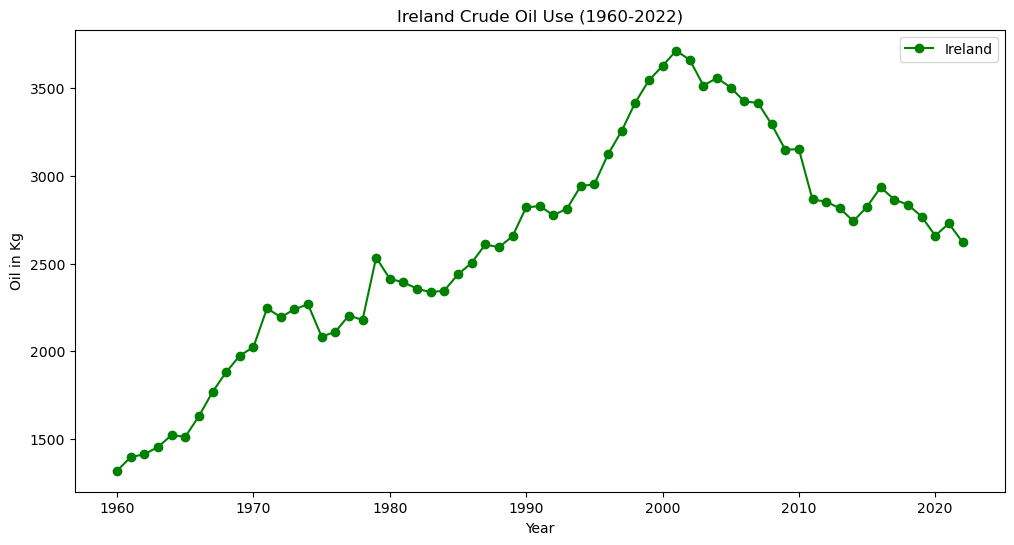

In [343]:
# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(ireland['Year'], ireland['Energy use'], label='Ireland', color='green', marker='o')
plt.title("Ireland Crude Oil Use (1960-2022)")
plt.xlabel("Year")
plt.ylabel("Oil in Kg")
plt.legend()
#plt.savefig('Crude_oil_IE_GR.png')
plt.show()

Line plot is initially created to see the trend of crude oil consumption (energy use) in the dataset. We can see that there are a few spikes in the dataset and data cannot be stationary. However, we can check the stationarity of the dataset by conducting ADF hypothesis testing.

### Plotting boxplots

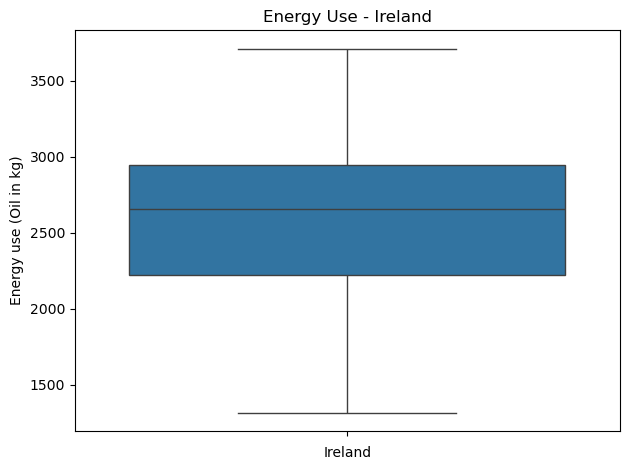

In [380]:
plt.figsize=(8, 5)

# Ireland boxplot (left)
sns.boxplot(data=ireland, y='Energy use')
plt.title('Energy Use - Ireland')
plt.xlabel('Ireland')
plt.ylabel('Energy use (Oil in kg)')

plt.tight_layout()
plt.show()

**Interpretation:**

The box plots provide a statistical summary of crude oil use distributions for Ireland and Germany over a period. The box plots is used to see the outliers and distribution in the dataset. 

Ireland's median crude oil use is around 2600 kg, with the middle 50% falling between 2200 kg (Q1) and 2950 kg (Q3). The whiskers extend from 1300 kg to 3700 kg, indicating the total spread of most data points over the years. There are no apparent outliers on the lower or upper ends, suggesting that while there is variability, there aren't exceptionally high or low years of crude oil consumption for Ireland relative to the overall distribution. 


### Plotting Histograms

**Interpretation:**

The histograms are plotted to see the central tendencies, but also the shape, spread, and frequency of different consumption levels of both countries. 
It provides a visual representation of the distribution of continuous data by grouping data into bins and displaying the frequency of observations within each bin.

The histogram for Ireland's crude oil use shows two prominent peaks, suggesting two distinct periods of consumption between 1960 and 2022. The most frequent range was between 2750 and 3000 kg. The data ranged from 1250 kg to 3750 kg, indicating a considerable spread in crude oil consumption over the years. The distribution seemed right-skewed, suggesting more years with moderately higher consumption than exceptionally low consumption. 


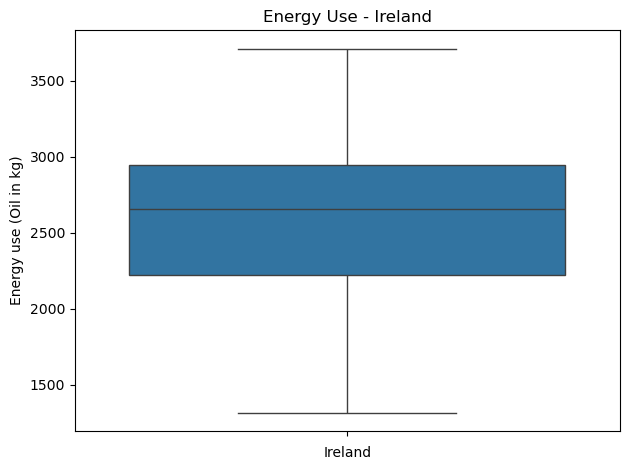

In [350]:
plt.figsize=(8, 5)

# Ireland boxplot (left)
sns.boxplot(data=ireland, y='Energy use')
plt.title('Energy Use - Ireland')
plt.xlabel('Ireland')
plt.ylabel('Energy use (Oil in kg)')

plt.tight_layout()
plt.show()

Outliers are being capped the third standard deviation since removing outliers can lose the critical data for time series analysis. Time series analysis relies on the past data to predict the future values

### Checking stationary 

In [353]:
# Import the Augmented Dickey-Fuller test function from statsmodels
from statsmodels.tsa.stattools import adfuller

# --- Context ---
# H₀ (Null Hypothesis): The data has a unit root (non-stationary).
# Small p-value (<0.05) → Reject H₀ → Data is stationary.
# Large p-value → Fail to reject H₀ → Data is non-stationary.

# Perform the ADF test on the energy use data for Ireland
result = adfuller(ireland['Energy use'])  
print('ADF Statistic:', result[0])  
print('p-value:', result[1])  
print('Critical Values:')  
for key, value in result[4].items():  
    print(f'{key}: {value}')  

# Interpret the result
if result[1] < 0.05:  
    print("Reject H₀: Data is stationary (no differencing needed)")  
else:  
    print("Fail to reject H₀: Data is non-stationary (differencing required)")  

ADF Statistic: -2.0782253006031004
p-value: 0.25335996878548167
Critical Values:
1%: -3.548493559596539
5%: -2.912836594776334
10%: -2.594129155766944
Fail to reject H₀: Data is non-stationary (differencing required)


**Interpretation:**

The ADF test is a crucial tool in time series analysis to assess the stationarity of a time series. Stationarity is a key property of data, as it helps in determining the correct order of differencing and identifying model identification issues. Time series models, such as ARIMA, rely on the assumption that the underlying process generating the data is stationary. If a series is non-stationary, it can lead to spurious correlations, unreliable forecasts, and model identification issues.

ADF Statistic result is -2.078. More negative values indicate stronger evidence against the presence of a unit root, which means more evidence for stationarity.

Since p-value is 0.25 which is above 0.05 threshold,  strongly supports null hypothesis. Data is non-stationary data.

Critical Values are threshold values from the Dickey-Fuller distribution at different significance levels (1%, 5%, and 10%). Critical values are compared against ADF statistic to make a decision about the null hypothesis.

+ 1%: -3.54: At a 1% significance level, it would reject the null hypothesis if  ADF statistic is less than -3.54.
+ 5%: -2.91: At a 5% significance level, it would reject the null hypothesis if  ADF statistic is less than -2.91.
+ 10%: -2.59: At a 10% significance level, it would reject the null hypothesis if ADF statistic is less than -2.59.

Since ADF test statistic is greater than all critical values, it fails to reject null hypothesis.

### Feature engineering

In [357]:
# Convert Year column to datetime index
ireland['Year'] = pd.to_datetime(ireland['Year'], format='%Y')
ireland.set_index('Year', inplace=True)

This code demonstrates to convert the 'Year' column of a 'ireland' DataFrame into a time index for time series analysis.

The 'ireland['Year']' function is used to convert the 'Year' column to datetime, allowing for time-based indexing, slicing, resampling, time-based plotting, and integration with time series models.

The 'ireland.set_index('Year', inplace=True) method sets the specified column as the index of the DataFrame, establishing the chronological order of the data.

This simplifies time-based operations to make time-based selection, aggregation, and analysis. The code also ensures compatibility with time series libraries, as many expect the time variable to be the index of the DataFrame. These steps are crucial for effectively utilizing the time-related functionalities of pandas and other time series analysis libraries for tasks like visualization, analysis, and modeling of energy use data over time.


In [359]:
# First difference & drop NaN
diff_data = ireland[['Energy use']].diff().dropna()

The 'Energy use' time series in Ireland is transformed into a stationary series by performing two operations (.diff() and.dropna()). The first difference is used to remove or reduce non-stationarity, specifically trends, which violate the assumption of stationarity required by time series models like ARIMA. This is a common first step in achieving stationarity in a time series.

The second operation,.dropna(), introduces a NaN value at the beginning of the resulting series due to differencing, ensuring a clean and usable differenced time series for further analysis and modeling. This is necessary to handle missing data and align the differenced series with its time index for further analysis.


In [361]:
diff_data.head()

,Energy use
Year,
1961-01-01,77.653665
1962-01-01,16.263525
1963-01-01,41.232429
1964-01-01,68.232868
1965-01-01,-10.290062


In [362]:
result_diff = adfuller(diff_data)
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])

if result_diff[1] < 0.05:
    print("Differenced data is stationary (proceed with ARIMA d=1)")
else:
    print("Still non-stationary → try higher-order differencing (d=2)")

ADF Statistic (Differenced): -2.971423183955964
p-value (Differenced): 0.037650674126284596
Differenced data is stationary (proceed with ARIMA d=1)


The Augmented Dickey-Fuller (ADF) test is used again to verify the success of a differencing step in making a time series stationary. This step is crucial as it helps determine the order of integration (d) in the ARIMA model. If the differenced data is stationary (p-value < 0.05), it means first differencing was enough to remove non-stationary components, allowing for the fitting of an ARIMA model with d=1. 

If the differenced data is still non-stationary (p-value >= 0.05), it suggests higher-order differencing is needed or different method of differencing should be applied. The iterative process of checking for stationarity after each differencing step ensures that the data meets the necessary conditions for the ARIMA model. This step is essential for ensuring the data meets the necessary conditions for achieving a stationary time series.

**Interpretation:**

The ADF test statistic on the first-differenced 'Energy use' series is -2.971423183955964, and the p-value is 0.037650674126284596. 

The p-value is below the significance level of 0.05, rejecting the null hypothesis that the time series has a unit root and is non-stationary. 

This results in sufficient statistical evidence to suggest that the first-differenced 'Energy use' data is stationary. To achieve stationarity, the order of integration in the ARIMA model should be set to 1. Analyzing the Autocorrelation Function and Partial Autocorrelation Function of the stationary data will help determine the appropriate orders for the autoregressive and moving average components.

### Plotting ACF and PACF

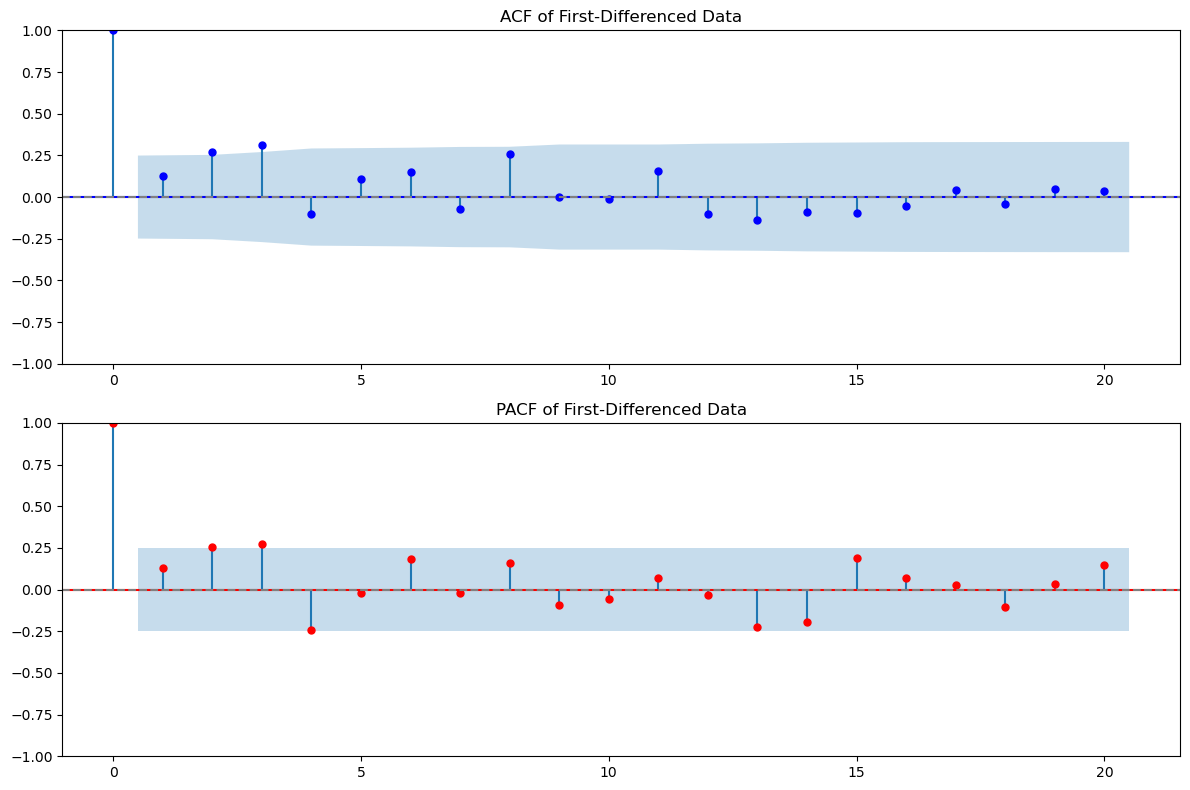

In [366]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# first differenced data
diff_data = ireland[['Energy use']].diff().dropna()

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF Plot (to identify MA order 'q')
plot_acf(diff_data, lags=20, ax=ax1, title='ACF of First-Differenced Data', color='blue')
ax1.axhline(y=0, linestyle='--', color='gray')

# PACF Plot (to identify AR order 'p')
plot_pacf(diff_data, lags=20, ax=ax2, title='PACF of First-Differenced Data', method='ywm', color='red')
ax2.axhline(y=0, linestyle='--', color='gray')

plt.tight_layout()
#plt.savefig('ACF_PACF_IE.png')
plt.show()

**Interpretation:**

The reason why we are plotting acf and pacf plots to identify the correct model order  ([DataCamp,n.d](Source:https://campus.datacamp.com/courses/arima-models-in-python/the-best-of-the-best-models?ex=1)).  

ACF measures the correlation between a data point and its lagged values, considering all intermediate lags. It gives a broad picture of how each observation is related to its past values [(GeeksforGeeks, 2025)](https://www.geeksforgeeks.org/understanding-partial-autocorrelation-functions-pacf-in-time-series-data/)). ACF (Autocorrelation Function) plot reveals a significant positive spike at lag 1, indicating a strong correlation between energy use changes in one period and the previous one. Autocorrelations decay gradually after the initial spike, with some spikes outside the confidence interval at lags 3, 6, and 10. These spikes suggest underlying cyclical patterns or dependencies in the data. 

Partial Autocorrelation Function (PACF) isolates the direct correlation between a data point and a specific lag, while controlling for the influence of other lags. It provides a more focused view of the relationship between a data point and its immediate past [(GeeksforGeeks, 2025)](https://www.geeksforgeeks.org/understanding-partial-autocorrelation-functions-pacf-in-time-series-data/)). PACF plot shows significant positive spikes at lags 1 and 2. Even after accounting for the influence of intermediate lags, the considerable surge at lag 1 keeps that changes in energy use are strongly related to changes in the immediately previous period. After accounting for the effect of the lag 1 change, the large spike at lag 2 indicates that the change in energy use is directly influenced by the change two periods ago.


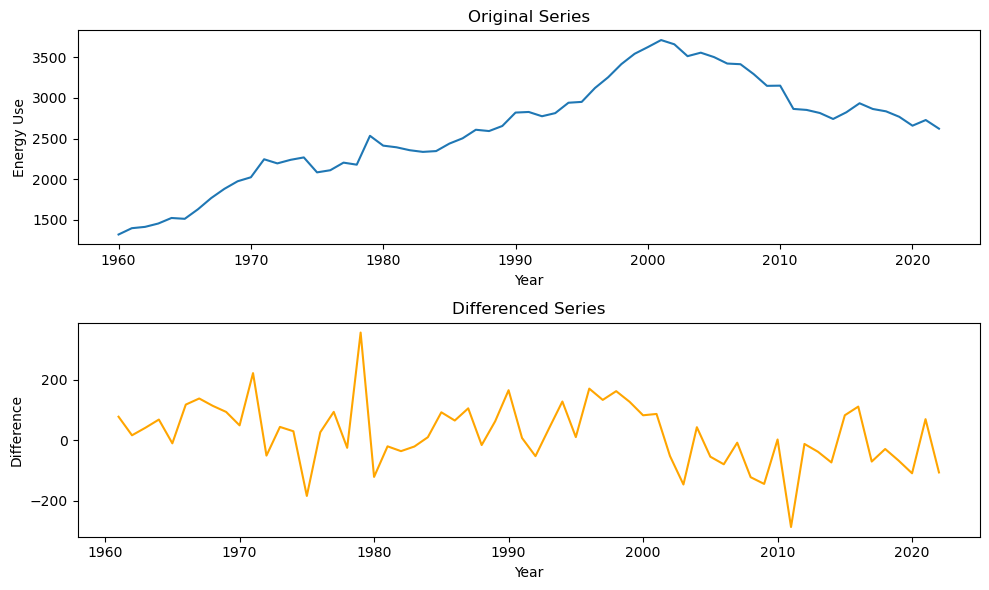

In [368]:
# Create a temporary DataFrame with reset index
temp_df = ireland.reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Plot using the Year column
ax1.plot(temp_df['Year'], temp_df['Energy use'], label='Original')
ax1.set_title('Original Series')
ax1.set_xlabel('Year')
ax1.set_ylabel('Energy Use')

# Plot differenced series
ax2.plot(temp_df['Year'].iloc[1:], diff_data, label='Differenced (1st Order)', color='orange')
ax2.set_title('Differenced Series')
ax2.set_xlabel('Year')
ax2.set_ylabel('Difference')

plt.tight_layout()
plt.savefig('IE_Org_Diff.png')
plt.show()

**Interpretation:**

Original Series (Energy Use): The plot shows a long-term upward trend in energy use from the 1960s to the late 2000s. The peak appears around the late 2000s, followed by a decline and stabilization. The original series is non-stationary due to the upward trend.

Differenced Series: The plot shows the first difference in energy use data, plotting the change from the previous year. It removes the upward trend, exhibiting significant volatility and spikes. The differenced series appears stationary, with a more consistent variance over time. To confirm stationarity, statistical tests like the Augmented Dickey-Fuller test are typically performed.

In [370]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p=1, d=1, q=1)
model = ARIMA(ireland['Energy use'], order=(1, 1, 1))  
ireland.index.freq = 'YS'
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:             Energy use   No. Observations:                   63
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -374.197
Date:                Mon, 19 May 2025   AIC                            754.393
Time:                        12:50:29   BIC                            760.775
Sample:                    01-01-1960   HQIC                           756.899
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8850      0.135      6.548      0.000       0.620       1.150
ma.L1         -0.7254      0.208     -3.491      0.000      -1.133      -0.318
sigma2      1.021e+04   1439.728      7.089      0.0

**Interpretation:**
  
+ AR(1): One autoregressive term, which means that the current value is forecasted using the value from one year ago.
+ I(1): Integrated of order 1, suggesting that the data was differenced once to establish stationarity.
+ MA(1): One moving average term, which means that the present value is influenced by the error term from one year ago.

ar.L1(0.8850): This coefficient of 0.8850 indicates that the change in energy usage in the current year is highly positively related to the change in energy use the previous year. The fact that the p-value (0.000) is low shows that this association is statistically significant. 

Confidence Interval: The range falls within [0.620, 1.150]: Since the interval does not include 0, the AR(1) term is statistically significant.

ma.L1's coeff: [-0.7254]: There is a moderately strong negative correlation with past error. Past error affects negatively to the today values.

sigma2 (Variance of residual [1.021e+04 (10,210)]: It represents the estimated variance of the model's residuals (noise). High variance indicates that the model cannot account for all the data's variability.

The Ljung-Box test at lag 1 shows no significant evidence of residual correlation in errors one year apart, indicating no autocorrelation. However, to understand the model's randomness, it's essential to examine it for higher lags, as significant autocorrelation at higher lags may indicate the model's inability to capture data dependencies.

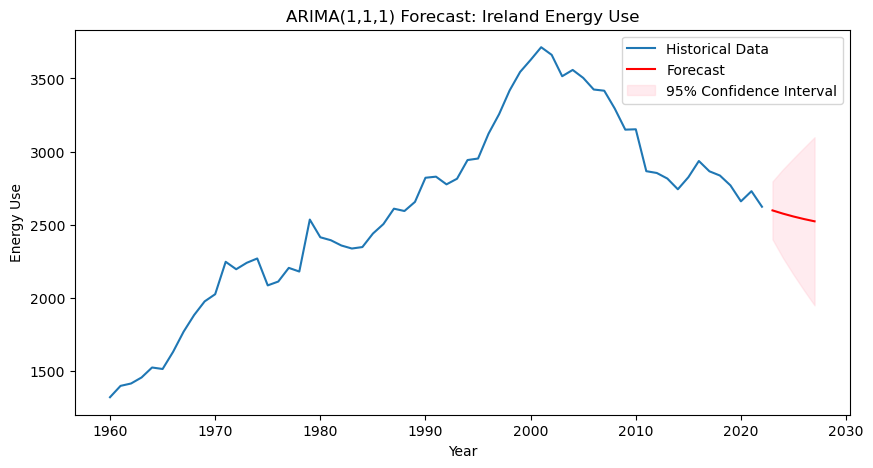

ARIMA(1,1,1) Forecasts:
2023-01-01    2597.046502
2024-01-01    2574.842814
2025-01-01    2555.192679
2026-01-01    2537.802423
2027-01-01    2522.412147
Freq: YS-JAN, Name: predicted_mean, dtype: float64

95% Confidence Intervals:
            lower Energy use  upper Energy use
2023-01-01       2399.035615       2795.057389
2024-01-01       2271.647201       2878.038428
2025-01-01       2157.361885       2953.023473
2026-01-01       2049.979431       3025.625415
2027-01-01       1947.504800       3097.319495


<Figure size 640x480 with 0 Axes>

In [372]:
ts_data = ireland['Energy use']  

# Fit ARIMA(1,1,1) model, first differencing
model = ARIMA(ts_data, order=(1, 1, 1))

#fit the model
results = model.fit()

# Generate Forecasts (next 5 years)
forecast_steps = 5
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)  # 95% confidence intervals

# Create future dates for the forecast
# Date labels for your future forecasts
last_date = ireland.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(years=1), periods=forecast_steps, freq='YS')
forecast_mean.index = future_dates
conf_int.index = future_dates

# Plot forecasts
plt.figure(figsize=(10, 5))
plt.plot(ireland['Energy use'], label='Historical Data')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval') 
plt.title('ARIMA(1,1,1) Forecast: Ireland Energy Use')
plt.xlabel('Year')
plt.ylabel('Energy Use')
plt.legend()
plt.show()
plt.savefig('ARIMA(1,1,1).png')

print("ARIMA(1,1,1) Forecasts:")
print(forecast_mean)
print("\n95% Confidence Intervals:")
print(conf_int)

**Interpretation:**

The code uses the ARIMA model to analyze and forecast energy use data from a DataFrame, generating predictions for the next 5 years and estimating the uncertainty in those predictions.

We use 95% confidence interval to show the uncertainty of the prediction. If we were to repeat this forecasting process many times, using different samples of historical data, 95% of the predicted value will catch the true future value and 5% will not be able to match with future value. 

The historical energy consumption in Ireland from 1960 to early 2020s is depicted, with a peak around 2000 and subsequent decline. The ARIMA(1,1,1) model predicts a gradual decrease in energy consumption from January 1, 2023, to January 1, 2027. The 95% confidence interval indicates a 95% probability of future energy use falling within this range, with increasing uncertainty for distant years.

ARIMA(1,1,1) Predictions (Table): The first table the graph shows the particular point forecast values (the red line) for each year from 2023 to 2027, beginning on January 1st of each year. For example, the projection for January 1, 2023 is around 2597.85.

95% Confidence Intervals (Table): The second table shows the lower and upper bounds of the 95% confidence intervals for each anticipated year. For example, on January 1, 2023, the model forecasts that actual energy use will be between 2399.04 and 2795.09. In 2027, we will notice that the range between the lower and upper boundaries of the confidence interval widens, representing the increased uncertainty in longer-term forecasts.

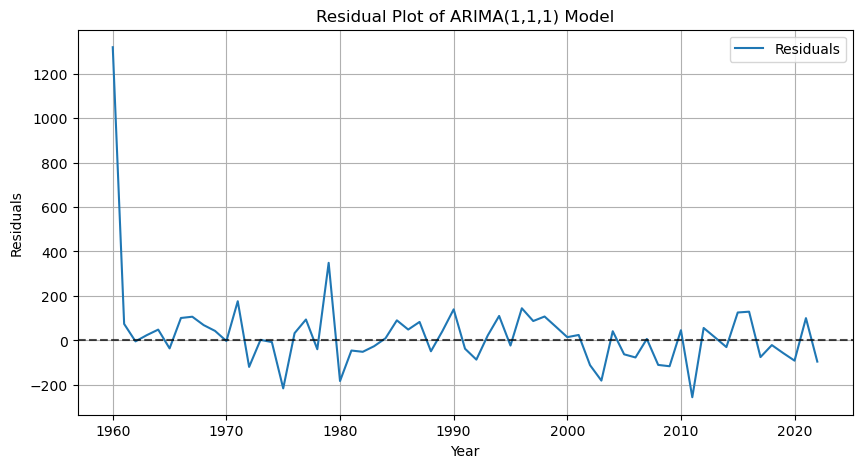

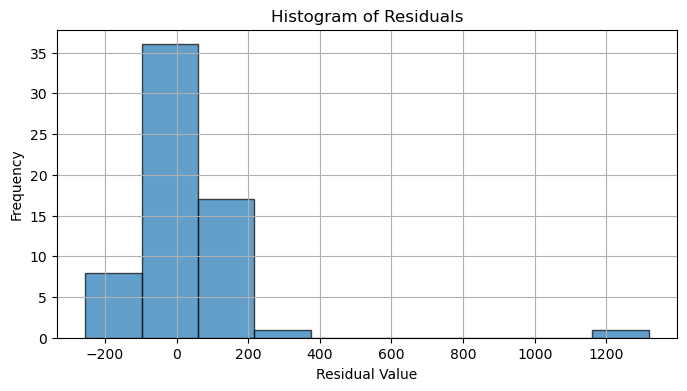

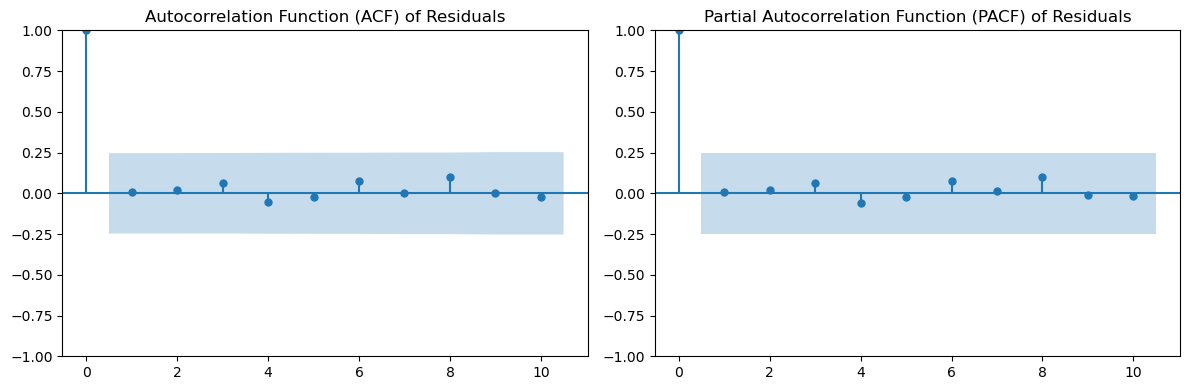

In [374]:
# Fit ARIMA(1,1,1) model
model = ARIMA(ts_data, order=(1, 1, 1))
results = model.fit()

# Get the residuals
residuals = results.resid

# Plot the residuals
plt.figure(figsize=(10, 5))
plt.plot(residuals, label='Residuals')
plt.title('Residual Plot of ARIMA(1,1,1) Model')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='k', linestyle='--', alpha=0.7)  # Add a horizontal line at zero
plt.legend()
plt.grid(True)
plt.show()

# You can also plot the distribution of the residuals (e.g., histogram)
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# And check the autocorrelation and partial autocorrelation of the residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, lags=10, ax=axes[0], title='Autocorrelation Function (ACF) of Residuals')
plot_pacf(residuals, lags=10, ax=axes[1], title='Partial Autocorrelation Function (PACF) of Residuals')
plt.tight_layout()
plt.savefig('rs.png')
plt.show()

**Interpretation:**

Residual analysis is a crucial step in evaluating the goodness of fit and the validity of a model's assumptions. It involves examining residuals, which represent the differences between observed and predicted values, to determine if the model has adequately captured the underlying patterns in the time series data.

The residuals are plotted over time, examining for systematic patterns, trends, or seasonality. If these patterns exist, it suggests that the ARIMA(1,1,1) model has not fully captured the underlying structure of the data and might need to be adjusted. Non-constant variance violates one of ARIMA models' assumptions and can affect the reliability of forecasts and confidence intervals.

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of residuals are also examined to check for significant correlations between the residuals at different lags. If significant spikes outside the blue confidence intervals indicate that the residuals are autocorrelated, it suggests that the ARIMA(1,1,1) model has not captured all the serial dependence in the data.


Residual Plot: The initial spike in residuals around 1960 suggests the model's inability to fit the early part of the series. Subsequent fluctuations suggest the model is not consistently over- or under-predicting. No obvious trends or seasonal cycles are evident after the initial period. 

Residual histogram: The residuals are mostly clustered around zero. However, the distribution is slightly skewed to the right, suggesting underprediction. The non-normal shape, with high residuals close to zero and a large outlier, suggests the residuals may not be perfectly normal.

ACF: The ACF plot reveals a significant spike at lag 1, indicating a statistically significant autocorrelation between a residual and the preceding residual. This suggests the model may not capture all short-term dependencies in the data, potentially leaving some information for further modeling. Autocorrelations mostly fall within the blue shaded region for lags greater than 1.

PACF: The PACF plot demonstrates the correlation between residuals at a specific lag, highlighting the direct effect of a past residual on the current one. A noticeable spike at lag 1 indicates a significant correlation, while partial autocorrelations for lags greater than 1 are mostly within the blue shaded region.

Short-Term reliance: The ACF and PACF plots show significant autocorrelation at lag 1, indicating that the ARIMA(1,1,1) model did not capture all of the residuals' short-term reliance. 

Non-Normality in the residuals: The histogram indicates that the residuals are not totally normal, with a slight positive skew and several possible outliers. While normal residuals are not required for ARIMA models to be consistent, substantial deviations might have an impact on statistical inference reliability.

### ARIMA Model with GridSearch 

Testing ARIMA combinations:
ARIMA(0, 1, 0) - AIC:757.29
ARIMA(0, 1, 1) - AIC:758.14
ARIMA(0, 1, 2) - AIC:752.59
ARIMA(1, 1, 0) - AIC:757.55
ARIMA(1, 1, 1) - AIC:754.39
ARIMA(1, 1, 2) - AIC:751.81
ARIMA(2, 1, 0) - AIC:754.64
ARIMA(2, 1, 1) - AIC:754.54
ARIMA(2, 1, 2) - AIC:748.10

Best Order: ARIMA(2, 1, 2) | AIC: 748.10 | Test RMSE: 86.30


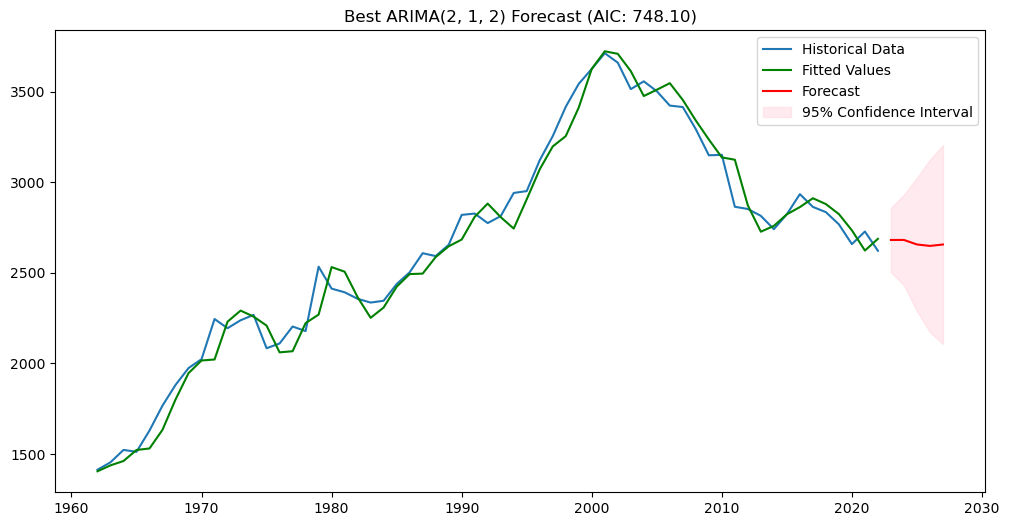

In [377]:
from itertools import product

# Modified parameter ranges
ts_data = ireland['Energy use']  

#ignore last five years
train = ts_data[:-5]

#only include last five years
test = ts_data[-5:]

p_range = range(0, 3)
d_range = range(1, 2)  
q_range = range(0, 3)

# ... rest of your grid search code ...
best_aic = np.inf
best_order = None
best_rmse = np.inf


# Grid search
print("Testing ARIMA combinations:")
for p, d, q in product(p_range, d_range, q_range):
    try:                
        model = ARIMA(ts_data, order=(p, d, q)).fit()
         # Calculate RMSE on test set
        forecast = model.get_forecast(steps=len(test))
        preds = forecast.predicted_mean
        rmse = np.sqrt(mean_squared_error(test, preds))
        
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = (p, d, q)
            best_rmse = rmse
        print(f'ARIMA{p,d,q} - AIC:{model.aic:.2f}')
    except:
        continue

print(f"\nBest Order: ARIMA{best_order} | AIC: {best_aic:.2f} | Test RMSE: {best_rmse:.2f}")


# Fit and forecast with the best model
best_model = ARIMA(ts_data, order=best_order).fit(method='innovations_mle')
forecast = best_model.get_forecast(steps=5)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()


# Plotting adjusted to remove initialization effects:
plt.figure(figsize=(12,6))

# Skip first 2
plt.plot(ts_data[2:], label='Historical Data') 
plt.plot(best_model.fittedvalues[2:], color='green', label='Fitted Values') 
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title(f'Best ARIMA{best_order} Forecast (AIC: {best_aic:.2f})')
plt.legend()
plt.savefig('ARIMA_2,1,2.png')
plt.show()

**Interpretation:**

We conduct the GridSearch to get the optimal order for ARIMA model. This method conducts an automatic search for the optimal ARIMA model order (within the defined ranges) by assessing their AIC on the complete dataset and predicting performance (RMSE) on a held-out test set. 

Before GridSearch, we split the data into train and test data. Training data will be taken ignoring last five years and test data will be taken for last five years. The reason for taking last five years is that the project aims to forecast based on the immediate past. 

Then, we set the range of search to perform GridSearch. 

Once the optimum order is determined, it refits the model on the entire dataset and generates a forecast for the next five periods, as well as a visualization of the results. The first two plot points are skipped to avoid displaying the initial unstable fitted values that occur as a result of the differencing required for stationarity in ARIMA models.

After GridSearch, the best model order with best root mean square error is (2,1,2). 

"Best ARIMA(2, 1, 2)": This indicates that an ARIMA model with an autoregressive order of 2, an integrated order of 1 (meaning the data was likely differenced once for stationarity), and a moving average order of 2 was found to be the "best" according to a specific criterion.

"(AIC: 748.10)": AIC stands for Akaike Information Criteria. It is a statistical metric used to compare various models. A lower AIC suggests a better balance between the model's fit to the data and its complexity (penalizing overfitting). The AIC value (748.10) was most likely the lowest of the models considered, hence the ARIMA(2, 1, 2) order was chosen as the "best."

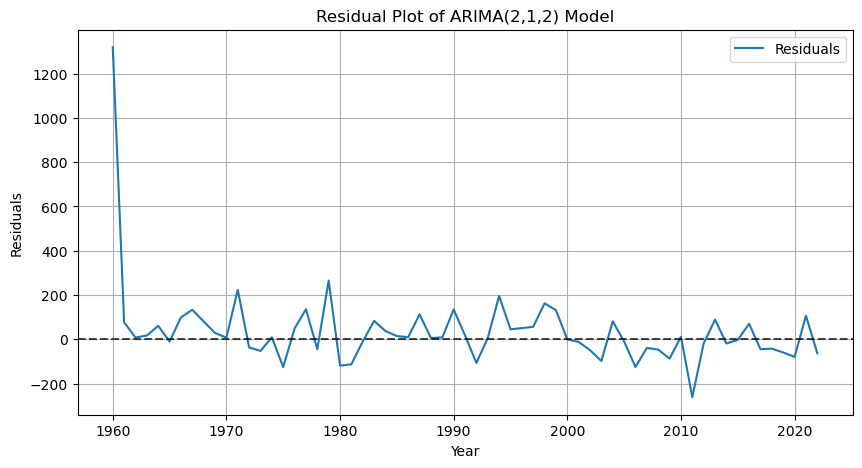

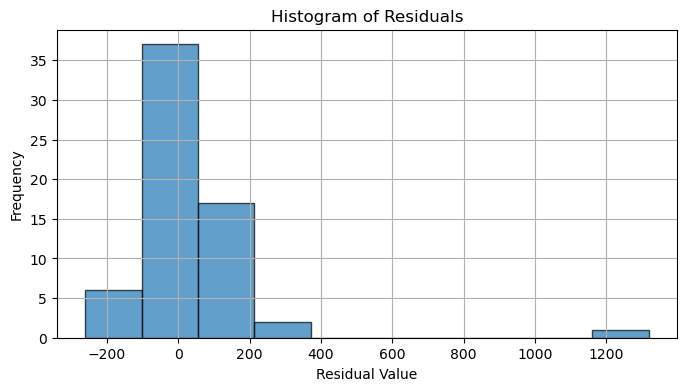

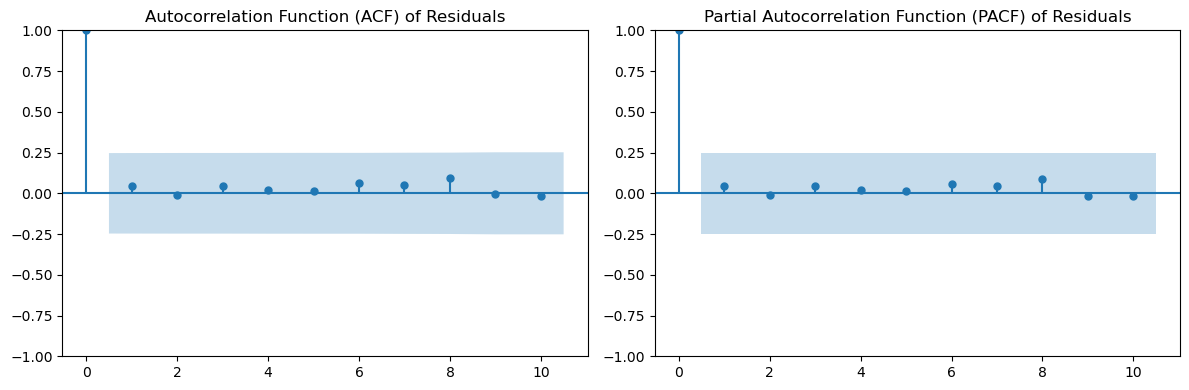

In [384]:
# Fit ARIMA(1,1,1) model
model = ARIMA(ts_data, order=(2, 1, 2))
results = model.fit()

# Get the residuals
residuals = results.resid

# Plot the residuals
plt.figure(figsize=(10, 5))
plt.plot(residuals, label='Residuals')
plt.title('Residual Plot of ARIMA(2,1,2) Model')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='k', linestyle='--', alpha=0.7)  # Add a horizontal line at zero
plt.legend()
plt.grid(True)
plt.show()

# You can also plot the distribution of the residuals (e.g., histogram)
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# And check the autocorrelation and partial autocorrelation of the residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, lags=10, ax=axes[0], title='Autocorrelation Function (ACF) of Residuals')
plot_pacf(residuals, lags=10, ax=axes[1], title='Partial Autocorrelation Function (PACF) of Residuals')
plt.tight_layout()
plt.show()

**Interpretation:**

Residual Plot:  Similar to the ARIMA(1,1,1) model, there is a significant positive residual at the start of 1960. After that, the residuals vary around the zero line. The variations may appear less unpredictable when compared to the ARIMA(1,1,1) plot, but there is no significant visual difference. The residuals continue to show no clear indication of persistent trends or seasonal patterns. A few stronger spikes (positive and negative) persist, indicating when the model's prediction error is still present. 

Residual histogram: The histogram shows a clustered distribution around zero, a slight positive skew, and a non-normal shape with a high concentration around zero, a noticeable bar, and a large outlier, similar to the ARIMA(1,1,1) residual histogram.

ACF: The ARIMA(2,1,2) model shows a reduced spike at lag 1, indicating better short-term autocorrelation compared to the ARIMA(1,1,1) model. Autocorrelations for lags greater than 1 remain within the blue shaded region, indicating no significant autocorrelation at longer lags.

PACF: The ARIMA(2,1,2) model effectively addresses short-term direct correlation between consecutive residuals by reducing the significant spike at lag 1, and ensuring partial autocorrelations for lags greater than 1 remain mostly within bounds.

**Challenges:**


1. Consistency in Data

   Since not all countries within European Union have records before 1990, the dataset that has all records from 1960 to 2022 were chosen in this study. The imputation of missing values could be done with the backward fill method for the countries with missing rows, as it is two of the best imputation method for time series analysis. However, this study intends to prevent the bias introduced by the backward fill method. 

2. Non-Normality of Data

    It is highly likely to get skewed data when the data points have increasing trends. Conducting parametric test such as t-test and Z-test requires normality to perform hypothesis testing successfully. The issues is tackled by conducting data transformation. Johnsonb transformation yields the best performance in achieving normality. 

3. Type I and Type II error

    The possibility of getting false positives and false negatives is high when performing various parametric and non-parametric tests. Correctly defining hypothesis statement was essential in this part.